#Install the required libraries

In [1]:
!pip install sentence-transformers
!pip install faiss-cpu
!pip install rank-bm25
!pip install transformers
!pip install accelerate
!pip install pandas
!pip install matplotlib
!pip install scikit-learn
!pip install tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 85.8 MB/s eta 0:00:00


#Load the review dataset

In [3]:
import gzip
import json
import random
import pandas as pd

DATASET_PATH = "All_Beauty.jsonl.gz"
DATASET_SAMPLE_SIZE = 50_000
EXPERIMENT_RANDOM_SEED = 42

random.seed(EXPERIMENT_RANDOM_SEED)

reviews = []
total_rows_seen = 0

with gzip.open(DATASET_PATH, "rt", encoding="utf-8") as f:
    for total_rows_seen, line in enumerate(f, start=1):
        record = json.loads(line)
        record["source_row_id"] = total_rows_seen - 1

        if len(reviews) < DATASET_SAMPLE_SIZE:
            reviews.append(record)
        else:
            replacement_position = random.randint(
                1,
                total_rows_seen
            )

            if replacement_position <= DATASET_SAMPLE_SIZE:
                reviews[replacement_position - 1] = record

df = pd.DataFrame(reviews)

sampling_metadata = {
    "dataset_path": DATASET_PATH,
    "sampling_method": "reservoir_sampling_over_full_jsonl_stream",
    "sample_size_target": DATASET_SAMPLE_SIZE,
    "sample_size_actual": len(df),
    "total_rows_seen": total_rows_seen,
    "random_seed": EXPERIMENT_RANDOM_SEED
}

print("Dataset sample shape:", df.shape)
print("Total rows scanned:", total_rows_seen)
print("Sampling method:", sampling_metadata["sampling_method"])
print("Random seed:", EXPERIMENT_RANDOM_SEED)

Dataset sample shape: (50000, 11)
Total rows scanned: 701528
Sampling method: reservoir_sampling_over_full_jsonl_stream
Random seed: 42


In [4]:
print("Columns:")
print(df.columns.tolist())

print("\nMissing text values:")
print(df["text"].isna().sum())

print("\nDuplicate reviews:")
print(df["text"].duplicated().sum())

print("\nExample reviews:")
display(df[["title", "text", "rating"]].head())

Columns:
['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase', 'source_row_id']

Missing text values:
0

Duplicate reviews:
2305

Example reviews:


,title,text,rating
0,Pass,Foil is too thin and the pad is flimsy falls o...,1.0
1,Worst thing ever.,It does not pick up the stones. Do not buy. Wa...,1.0
2,Yes!,"Smells good, feels great!",5.0
3,Little guy.,I am a huge fan of everything San-X so this wa...,4.0
4,Nope,Vasaline on a stick.,1.0


#Creating Source ID

In [5]:
if "source_row_id" not in df.columns:
    df["source_row_id"] = df.index

#Define the text-cleaning function

In [6]:
import re

def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()

    # Remove web addresses
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # Keep letters, numbers and spaces
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Replace repeated spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [7]:
df["original_text"] = df["text"]

df["clean_text"] = df["original_text"].apply(clean_text)

In [8]:
df["clean_text_length"] = df["clean_text"].str.len()
df["word_count"] = df["clean_text"].str.split().str.len()

In [9]:
before_filtering = len(df)

df = df[
    (df["clean_text"].notna()) &
    (df["word_count"] >= 5)
].copy()

after_filtering = len(df)

print("Reviews before filtering:", before_filtering)
print("Reviews after filtering:", after_filtering)
print("Removed reviews:", before_filtering - after_filtering)

Reviews before filtering: 50000
Reviews after filtering: 43294
Removed reviews: 6706


In [10]:
before_duplicates = len(df)

df = df.drop_duplicates(
    subset=["clean_text"],
    keep="first"
).copy()

after_duplicates = len(df)

print("Duplicates removed:", before_duplicates - after_duplicates)

Duplicates removed: 113


In [11]:
df = df.reset_index(drop=True)

df["doc_id"] = df.index.astype(int)

#Check the uniqueness

In [12]:
assert df["doc_id"].is_unique
assert df["clean_text"].notna().all()
assert (df["word_count"] >= 5).all()

print("Final number of documents:", len(df))

Final number of documents: 43181


#Create retrieval variables


In [13]:
documents = df["clean_text"].tolist()
original_documents = df["original_text"].tolist()
document_ids = df["doc_id"].tolist()

print("Documents:", len(documents))
print("Original documents:", len(original_documents))
print("Document IDs:", len(document_ids))

Documents: 43181
Original documents: 43181
Document IDs: 43181


In [14]:
document_position = 100

print("Document ID:", document_ids[document_position])
print("Clean text:", documents[document_position])
print("Original text:", original_documents[document_position])

Document ID: 100
Clean text: love these tattoos they work great they re really pretty and colorful
Original text: Love these tattoos they work great they’re really pretty and colorful


#Keep Useful Metadata

In [15]:
metadata_columns = [
    "doc_id",
    "source_row_id",
    "asin",
    "rating",
    "title",
    "original_text",
    "clean_text",
    "word_count"
]

reviews_df = df[metadata_columns].copy()

display(reviews_df.head())

,doc_id,source_row_id,asin,rating,title,original_text,clean_text,word_count
0,0,672561,B089N4FX5D,1.0,Pass,Foil is too thin and the pad is flimsy falls o...,foil is too thin and the pad is flimsy falls o...,13
1,1,522597,B088LRYC66,1.0,Worst thing ever.,It does not pick up the stones. Do not buy. Wa...,it does not pick up the stones do not buy warn...,25
2,2,193714,B003Y602L4,4.0,Little guy.,I am a huge fan of everything San-X so this wa...,i am a huge fan of everything san x so this wa...,131
3,3,432929,B00CUF29WU,5.0,A must have,Our entire family loves this nourishing oil - ...,our entire family loves this nourishing oil fr...,33
4,4,115627,B015ZXMSFQ,5.0,Feels so good on the skin!,This mask is so luxurious and feels heavenly o...,this mask is so luxurious and feels heavenly o...,45


In [16]:
reviews_df.to_csv(
    "prepared_beauty_reviews.csv",
    index=False
)

print("Prepared dataset saved.")

Prepared dataset saved.


In [17]:
df = reviews_df.copy()
documents = df["clean_text"].tolist()
original_documents = df["original_text"].tolist()

In [18]:
print("Final dataset summary")
print("---------------------")
print("Number of reviews:", len(df))
print("Unique document IDs:", df["doc_id"].nunique())
print("Unique cleaned reviews:", df["clean_text"].nunique())
print("Missing cleaned text:", df["clean_text"].isna().sum())
print("Minimum word count:", df["word_count"].min())
print("Average word count:", round(df["word_count"].mean(), 2))

display(
    df[
        [
            "doc_id",
            "rating",
            "title",
            "original_text",
            "clean_text",
            "word_count"
        ]
    ].head(10)
)

Final dataset summary
---------------------
Number of reviews: 43181
Unique document IDs: 43181
Unique cleaned reviews: 43181
Missing cleaned text: 0
Minimum word count: 5
Average word count: 38.63


,doc_id,rating,title,original_text,clean_text,word_count
0,0,1.0,Pass,Foil is too thin and the pad is flimsy falls o...,foil is too thin and the pad is flimsy falls o...,13
1,1,1.0,Worst thing ever.,It does not pick up the stones. Do not buy. Wa...,it does not pick up the stones do not buy warn...,25
2,2,4.0,Little guy.,I am a huge fan of everything San-X so this wa...,i am a huge fan of everything san x so this wa...,131
3,3,5.0,A must have,Our entire family loves this nourishing oil - ...,our entire family loves this nourishing oil fr...,33
4,4,5.0,Feels so good on the skin!,This mask is so luxurious and feels heavenly o...,this mask is so luxurious and feels heavenly o...,45
5,5,4.0,"Gold, and a bit small!","The wig is pretty good in quality, but it is s...",the wig is pretty good in quality but it is sm...,83
6,6,5.0,!!!,Hair is worth every penny and actually more lo...,hair is worth every penny and actually more lo...,22
7,7,1.0,Not worth it,Brushes did not stay in once spinning began.,brushes did not stay in once spinning began,8
8,8,5.0,Buy right now,Very comparable to the Ardell Demi wispies. Am...,very comparable to the ardell demi wispies ama...,37
9,9,5.0,PERFECT!,"Love, love, love, Kristopher Buckle! I have t...",love love love kristopher buckle i have tried ...,19


In [19]:
print("DataFrame rows:", len(df))
print("Clean documents:", len(documents))
print("Original documents:", len(original_documents))

assert len(df) == len(documents)
assert len(df) == len(original_documents)
assert df["doc_id"].is_unique
assert df["doc_id"].tolist() == list(range(len(df)))

print("Phase 1 alignment check passed.")

DataFrame rows: 43181
Clean documents: 43181
Original documents: 43181
Phase 1 alignment check passed.


In [20]:
!pip install -q rank-bm25 faiss-cpu sentence-transformers

In [21]:
import numpy as np
import pandas as pd
import faiss

from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer

#Build the BM25 Index

In [22]:
tokenized_documents = [
    document.split()
    for document in documents
]

print("Tokenized documents:", len(tokenized_documents))
print("Example tokens:", tokenized_documents[0][:20])

Tokenized documents: 43181
Example tokens: ['foil', 'is', 'too', 'thin', 'and', 'the', 'pad', 'is', 'flimsy', 'falls', 'off', 'the', 'foil']


Build the index

In [23]:
bm25 = BM25Okapi(tokenized_documents)

print("BM25 index created.")

BM25 index created.


In [24]:
def retrieve_bm25(query, k=10):
    cleaned_query = clean_text(query)
    query_tokens = cleaned_query.split()

    scores = bm25.get_scores(query_tokens)

    top_indices = np.argsort(scores)[::-1][:k]

    results = []

    for rank, index_position in enumerate(top_indices, start=1):
        row = df.iloc[index_position]

        results.append({
            "doc_id": int(row["doc_id"]),
            "title": row.get("title", ""),
            "rating": row.get("rating", ""),
            "text": row["original_text"],
            "clean_text": row["clean_text"],
            "score": float(scores[index_position]),
            "rank": rank
        })

    return results

In [25]:
bm25_results = retrieve_bm25(
    "best moisturizer for dry skin",
    k=5
)

for result in bm25_results:
    print("Rank:", result["rank"])
    print("Document ID:", result["doc_id"])
    print("Score:", result["score"])
    print("Review:", result["text"][:300])
    print("-" * 80)

Rank: 1
Document ID: 29985
Score: 17.263974467926896
Review: The best moisturizer I have ever used and I have used plenty. Heavy duty, takes care of winter dry skin overnight.
--------------------------------------------------------------------------------
Rank: 2
Document ID: 20860
Score: 15.264142523841112
Review: Use a moisturizer after if you have dry skin because this really dries out the skin .
--------------------------------------------------------------------------------
Rank: 3
Document ID: 39210
Score: 14.806546090252464
Review: This is a wonderful light moisturizer for my dry older skin.  I makes foundation go on smoothly.
--------------------------------------------------------------------------------
Rank: 4
Document ID: 35224
Score: 14.7265059394332
Review: The best washcloth for my dry, sensitive skin.
--------------------------------------------------------------------------------
Rank: 5
Document ID: 27992
Score: 14.444632723210558
Review: Best moisturizer I’ve ever u

#Load the embedding models

In [26]:
embedder = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

print("Embedding model loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded.


#Create Document Embeddings


In [27]:
embeddings = embedder.encode(
    documents,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_numpy=True
).astype("float32")

Batches:   0%|          | 0/675 [00:00<?, ?it/s]

#Checking the results


In [28]:
print("Embedding shape:", embeddings.shape)
print("Embedding data type:", embeddings.dtype)

assert embeddings.shape[0] == len(df)
assert embeddings.dtype == np.float32

Embedding shape: (43181, 384)
Embedding data type: float32


#Build the FAISS Index

In [29]:
embedding_dimension = embeddings.shape[1]

faiss_index = faiss.IndexFlatIP(embedding_dimension)
faiss_index.add(embeddings)

print("FAISS documents indexed:", faiss_index.ntotal)

assert faiss_index.ntotal == len(df)

FAISS documents indexed: 43181


#Create the FAISS retrieval function

In [30]:
def retrieve_faiss(query, k=10):
    cleaned_query = clean_text(query)

    query_embedding = embedder.encode(
        [cleaned_query],
        normalize_embeddings=True,
        convert_to_numpy=True
    ).astype("float32")

    scores, indices = faiss_index.search(
        query_embedding,
        k
    )

    results = []

    for rank, (index_position, score) in enumerate(
        zip(indices[0], scores[0]),
        start=1
    ):
        if index_position == -1:
            continue

        row = df.iloc[int(index_position)]

        results.append({
            "doc_id": int(row["doc_id"]),
            "title": row.get("title", ""),
            "rating": row.get("rating", ""),
            "text": row["original_text"],
            "clean_text": row["clean_text"],
            "score": float(score),
            "rank": rank
        })

    return results

In [31]:
faiss_results = retrieve_faiss(
    "best moisturizer for dry skin",
    k=5
)

for result in faiss_results:
    print("Rank:", result["rank"])
    print("Document ID:", result["doc_id"])
    print("Score:", result["score"])
    print("Review:", result["text"][:300])
    print("-" * 80)

Rank: 1
Document ID: 29985
Score: 0.8185706734657288
Review: The best moisturizer I have ever used and I have used plenty. Heavy duty, takes care of winter dry skin overnight.
--------------------------------------------------------------------------------
Rank: 2
Document ID: 2083
Score: 0.7790493965148926
Review: This product is excellent for dry skin.
--------------------------------------------------------------------------------
Rank: 3
Document ID: 24313
Score: 0.7781382203102112
Review: I was skeptical at first. I have very dry skin, well except my face. It is rare to find a moisturizer that hydrates your skin and also does not leave you greasy! I have been using elta MD sunscreen, face wash, and face cream for a while now. So I thought I'd give this moisturizer a try, and I am gla
--------------------------------------------------------------------------------
Rank: 4
Document ID: 27992
Score: 0.7710500359535217
Review: Best moisturizer I’ve ever used. Expensive for the small a

#Build Efficient Hybrid Retrieval

In [32]:
def min_max_normalize(score_dictionary):
    if not score_dictionary:
        return {}

    values = np.array(
        list(score_dictionary.values()),
        dtype=float
    )

    minimum = values.min()
    maximum = values.max()

    if maximum == minimum:
        return {
            doc_id: 1.0
            for doc_id in score_dictionary
        }

    return {
        doc_id: (score - minimum) / (maximum - minimum)
        for doc_id, score in score_dictionary.items()
    }

In [33]:
def retrieve_hybrid(
    query,
    k=10,
    candidate_k=100,
    bm25_weight=0.5,
    faiss_weight=0.5
):
    if not np.isclose(bm25_weight + faiss_weight, 1.0):
        raise ValueError(
            "BM25 and FAISS weights must add up to 1."
        )

    cleaned_query = clean_text(query)

    # BM25 candidates
    bm25_scores_all = bm25.get_scores(
        cleaned_query.split()
    )

    bm25_indices = np.argsort(
        bm25_scores_all
    )[::-1][:candidate_k]

    bm25_candidate_scores = {
        int(index_position):
        float(bm25_scores_all[index_position])
        for index_position in bm25_indices
    }

    # FAISS candidates
    query_embedding = embedder.encode(
        [cleaned_query],
        normalize_embeddings=True,
        convert_to_numpy=True
    ).astype("float32")

    dense_scores, dense_indices = faiss_index.search(
        query_embedding,
        candidate_k
    )

    faiss_candidate_scores = {
        int(index_position): float(score)
        for index_position, score in zip(
            dense_indices[0],
            dense_scores[0]
        )
        if index_position != -1
    }

    # Combine candidates from both methods
    candidate_indices = (
        set(bm25_candidate_scores.keys()) |
        set(faiss_candidate_scores.keys())
    )

    # Normalize only across the combined candidate pool
    bm25_pool_scores = {
        index_position:
        float(bm25_scores_all[index_position])
        for index_position in candidate_indices
    }

    faiss_pool_scores = {
        index_position:
        float(np.dot(
            embeddings[index_position],
            query_embedding[0]
        ))
        for index_position in candidate_indices
    }

    bm25_normalized = min_max_normalize(
        bm25_pool_scores
    )

    faiss_normalized = min_max_normalize(
        faiss_pool_scores
    )

    combined_results = []

    for index_position in candidate_indices:
        hybrid_score = (
            bm25_weight *
            bm25_normalized[index_position]
            +
            faiss_weight *
            faiss_normalized[index_position]
        )

        combined_results.append(
            (index_position, hybrid_score)
        )

    combined_results.sort(
        key=lambda item: item[1],
        reverse=True
    )

    top_results = combined_results[:k]
    results = []

    for rank, (index_position, score) in enumerate(
        top_results,
        start=1
    ):
        row = df.iloc[index_position]

        results.append({
            "doc_id": int(row["doc_id"]),
            "title": row.get("title", ""),
            "rating": row.get("rating", ""),
            "text": row["original_text"],
            "clean_text": row["clean_text"],
            "score": float(score),
            "bm25_score": float(
                bm25_normalized[index_position]
            ),
            "faiss_score": float(
                faiss_normalized[index_position]
            ),
            "rank": rank
        })

    return results

In [34]:
hybrid_results = retrieve_hybrid(
    "best moisturizer for dry skin",
    k=5
)

for result in hybrid_results:
    print("Rank:", result["rank"])
    print("Document ID:", result["doc_id"])
    print("Hybrid score:", round(result["score"], 4))
    print("BM25 component:", round(result["bm25_score"], 4))
    print("FAISS component:", round(result["faiss_score"], 4))
    print("Review:", result["text"][:300])
    print("-" * 80)

Rank: 1
Document ID: 29985
Hybrid score: 1.0
BM25 component: 1.0
FAISS component: 1.0
Review: The best moisturizer I have ever used and I have used plenty. Heavy duty, takes care of winter dry skin overnight.
--------------------------------------------------------------------------------
Rank: 2
Document ID: 27992
Hybrid score: 0.8626
BM25 component: 0.8367
FAISS component: 0.8885
Review: Best moisturizer I’ve ever used. Expensive for the small amount but worth it if you value your skin
--------------------------------------------------------------------------------
Rank: 3
Document ID: 39363
Hybrid score: 0.8265
BM25 component: 0.7954
FAISS component: 0.8576
Review: Absolutely the best product I’ve found for my very dry skin.
--------------------------------------------------------------------------------
Rank: 4
Document ID: 41117
Hybrid score: 0.7812
BM25 component: 0.7664
FAISS component: 0.796
Review: Absolutely the best moisturizer ever
------------------------------------------

#Create common Dictionary

In [35]:
retrieval_methods = {
    "BM25": retrieve_bm25,
    "FAISS": retrieve_faiss,
    "Hybrid": retrieve_hybrid
}

Testing all methods

In [36]:
test_query = "fragrance free cleanser for sensitive skin"

for method_name, retrieval_function in retrieval_methods.items():
    print("\nMETHOD:", method_name)

    results = retrieval_function(
        test_query,
        k=5
    )

    for result in results:
        print(
            result["rank"],
            result["doc_id"],
            round(result["score"], 4),
            result["text"][:150]
        )


METHOD: BM25
1 9509 17.7951 great for sensitive skin, dry eyes, no fragrance, just awesome cream.
2 17642 16.607 Very nice cleanser, it's definitely not too harsh for my sensitive skin and feels like a refreshing deep cleanse.
3 16779 16.5472 I have very sensitive and breakout skin. This cleanser keeps my facial skin hydrated, unlike other brands. I would recommend if you have these followi
4 36065 16.1324 This goat milk hand cream moisturizer is great for my sensitive skin and the fragrance is great.
5 10584 16.1271 I love this facial cleanser. I’ve always had very sensitive skin and was paying for top brands until I found this.

METHOD: FAISS
1 18536 0.7163 Smells great, good for sensitive skin, and really leaves your face feeling fresh!
2 9240 0.7069 Great for sensitive skin . Smells good
3 341 0.7068 I tried Majestic Pure Cosmoceutucals body scrub and it left my skin soft and smooth. It feels amazing. When I opened the jar, the fruity scent gave me
4 38186 0.7067 This is a good fa

#Validate the return format

In [37]:
required_keys = {
    "doc_id",
    "text",
    "clean_text",
    "score",
    "rank"
}

for method_name, retrieval_function in retrieval_methods.items():
    results = retrieval_function(
        "waterproof mascara",
        k=5
    )

    assert len(results) == 5

    for result in results:
        assert required_keys.issubset(result.keys())
        assert isinstance(result["doc_id"], int)
        assert result["text"] != ""

    returned_ids = [
        result["doc_id"]
        for result in results
    ]

    assert len(returned_ids) == len(set(returned_ids))

    print(method_name, "passed.")

BM25 passed.
FAISS passed.
Hybrid passed.


In [38]:
np.save(
    "beauty_review_embeddings.npy",
    embeddings
)

In [39]:
faiss.write_index(
    faiss_index,
    "beauty_reviews_faiss.index"
)

In [40]:
embeddings = np.load(
    "beauty_review_embeddings.npy"
).astype("float32")

faiss_index = faiss.read_index(
    "beauty_reviews_faiss.index"
)

In [41]:
tokenized_documents = [
    document.split()
    for document in documents
]

bm25 = BM25Okapi(tokenized_documents)

In [42]:
print("Final Phase 2 validation")
print("------------------------")
print("Documents:", len(df))
print("Embeddings:", embeddings.shape)
print("FAISS index size:", faiss_index.ntotal)
print("BM25 documents:", len(tokenized_documents))

assert len(df) == len(tokenized_documents)
assert len(df) == embeddings.shape[0]
assert len(df) == faiss_index.ntotal

for method_name, method in retrieval_methods.items():
    results = method(
        "hydrating serum for dry sensitive skin",
        k=10
    )

    print(
        method_name,
        "- returned",
        len(results),
        "documents"
    )

print("Phase 2 completed successfully.")

Final Phase 2 validation
------------------------
Documents: 43181
Embeddings: (43181, 384)
FAISS index size: 43181
BM25 documents: 43181
BM25 - returned 10 documents
FAISS - returned 10 documents
Hybrid - returned 10 documents
Phase 2 completed successfully.


Using a Complete Query Set

In [43]:
query_rows = [
    {
        "query_id": "Q01",
        "query": "best moisturizer for dry skin",
        "category": "skin concern"
    },
    {
        "query_id": "Q02",
        "query": "long lasting lipstick",
        "category": "product feature"
    },
    {
        "query_id": "Q03",
        "query": "anti aging cream for wrinkles",
        "category": "skin concern"
    },
    {
        "query_id": "Q04",
        "query": "shampoo for thinning hair",
        "category": "hair concern"
    },
    {
        "query_id": "Q05",
        "query": "fragrance free cleanser for sensitive skin",
        "category": "restriction"
    },
    {
        "query_id": "Q06",
        "query": "hydrating serum for dry skin",
        "category": "skin concern"
    },
    {
        "query_id": "Q07",
        "query": "natural deodorant for sensitive skin",
        "category": "natural product"
    },
    {
        "query_id": "Q08",
        "query": "waterproof mascara",
        "category": "product feature"
    },
    {
        "query_id": "Q09",
        "query": "foundation for oily skin",
        "category": "skin type"
    },
    {
        "query_id": "Q10",
        "query": "sunscreen without white residue",
        "category": "product feature"
    },
    {
        "query_id": "Q11",
        "query": "concealer for dark under eye circles",
        "category": "skin concern"
    },
    {
        "query_id": "Q12",
        "query": "gentle face wash for acne prone skin",
        "category": "skin concern"
    },
    {
        "query_id": "Q13",
        "query": "conditioner for damaged hair",
        "category": "hair concern"
    },
    {
        "query_id": "Q14",
        "query": "curl defining cream without stiffness",
        "category": "hair type"
    },
    {
        "query_id": "Q15",
        "query": "hair oil for frizzy hair",
        "category": "hair concern"
    },
    {
        "query_id": "Q16",
        "query": "volumizing shampoo for fine hair",
        "category": "hair type"
    },
    {
        "query_id": "Q17",
        "query": "body lotion for very dry skin",
        "category": "skin concern"
    },
    {
        "query_id": "Q18",
        "query": "hand cream for cracked hands",
        "category": "skin concern"
    },
    {
        "query_id": "Q19",
        "query": "lip balm for chapped lips",
        "category": "skin concern"
    },
    {
        "query_id": "Q20",
        "query": "lightweight moisturizer for oily skin",
        "category": "skin type"
    },
    {
        "query_id": "Q21",
        "query": "alcohol free toner for sensitive skin",
        "category": "restriction"
    },
    {
        "query_id": "Q22",
        "query": "paraben free shampoo",
        "category": "restriction"
    },
    {
        "query_id": "Q23",
        "query": "sulfate free shampoo for curly hair",
        "category": "restriction"
    },
    {
        "query_id": "Q24",
        "query": "cruelty free mascara",
        "category": "ethical preference"
    },
    {
        "query_id": "Q25",
        "query": "vegan lipstick with long wear",
        "category": "ethical preference"
    },
    {
        "query_id": "Q26",
        "query": "face serum for dark spots",
        "category": "skin concern"
    },
    {
        "query_id": "Q27",
        "query": "eye cream for puffiness",
        "category": "skin concern"
    },
    {
        "query_id": "Q28",
        "query": "retinol cream for beginners",
        "category": "user requirement"
    },
    {
        "query_id": "Q29",
        "query": "makeup remover for waterproof makeup",
        "category": "product feature"
    },
    {
        "query_id": "Q30",
        "query": "nail polish that dries quickly",
        "category": "product feature"
    },
    {
        "query_id": "Q31",
        "query": "strong hold hairspray without stickiness",
        "category": "product feature"
    },
    {
        "query_id": "Q32",
        "query": "heat protectant for damaged hair",
        "category": "hair concern"
    },
    {
        "query_id": "Q33",
        "query": "exfoliating scrub for sensitive skin",
        "category": "multi-condition"
    },
    {
        "query_id": "Q34",
        "query": "moisturizer suitable under makeup",
        "category": "usage requirement"
    },
    {
        "query_id": "Q35",
        "query": "non greasy sunscreen for oily skin",
        "category": "multi-condition"
    },
    {
        "query_id": "Q36",
        "query": "shampoo for color treated hair",
        "category": "hair concern"
    },
    {
        "query_id": "Q37",
        "query": "unscented body lotion",
        "category": "restriction"
    },
    {
        "query_id": "Q38",
        "query": "transfer resistant foundation",
        "category": "product feature"
    },
    {
        "query_id": "Q39",
        "query": "eyeliner that does not smudge",
        "category": "product feature"
    },
    {
        "query_id": "Q40",
        "query": "gentle exfoliant for acne prone skin",
        "category": "multi-condition"
    }
]

queries_df = pd.DataFrame(query_rows)

display(queries_df)
print("Number of queries:", len(queries_df))

,query_id,query,category
0,Q01,best moisturizer for dry skin,skin concern
1,Q02,long lasting lipstick,product feature
2,Q03,anti aging cream for wrinkles,skin concern
3,Q04,shampoo for thinning hair,hair concern
4,Q05,fragrance free cleanser for sensitive skin,restriction
5,Q06,hydrating serum for dry skin,skin concern
6,Q07,natural deodorant for sensitive skin,natural product
7,Q08,waterproof mascara,product feature
8,Q09,foundation for oily skin,skin type
9,Q10,sunscreen without white residue,product feature


Number of queries: 40


#Check whether products exists in Dataset

In [44]:
query_check_rows = []

for _, query_row in queries_df.iterrows():
    query_id = query_row["query_id"]
    query = query_row["query"]

    for method_name, retrieval_function in retrieval_methods.items():
        results = retrieval_function(query, k=10)

        query_check_rows.append({
            "query_id": query_id,
            "query": query,
            "method": method_name,
            "results_returned": len(results),
            "top_score": (
                results[0]["score"]
                if results else None
            )
        })

query_check_df = pd.DataFrame(query_check_rows)

display(query_check_df.head(15))

,query_id,query,method,results_returned,top_score
0,Q01,best moisturizer for dry skin,BM25,10,17.263974
1,Q01,best moisturizer for dry skin,FAISS,10,0.818571
2,Q01,best moisturizer for dry skin,Hybrid,10,1.000000
3,Q02,long lasting lipstick,BM25,10,20.311064
4,Q02,long lasting lipstick,FAISS,10,0.790466
5,Q02,long lasting lipstick,Hybrid,10,0.911835
6,Q03,anti aging cream for wrinkles,BM25,10,25.619863
7,Q03,anti aging cream for wrinkles,FAISS,10,0.817474
8,Q03,anti aging cream for wrinkles,Hybrid,10,1.000000
9,Q04,shampoo for thinning hair,BM25,10,14.815467


In [45]:
def inspect_query(query_id, results_per_method=5):
    matching_rows = queries_df[
        queries_df["query_id"] == query_id
    ]

    if matching_rows.empty:
        print("Unknown query ID.")
        return

    query = matching_rows.iloc[0]["query"]

    print("=" * 100)
    print("QUERY ID:", query_id)
    print("QUERY:", query)
    print("=" * 100)

    for method_name, retrieval_function in retrieval_methods.items():
        print("\nMETHOD:", method_name)
        print("-" * 100)

        results = retrieval_function(
            query,
            k=results_per_method
        )

        for result in results:
            print(
                "Rank:",
                result["rank"],
                "| Doc ID:",
                result["doc_id"],
                "| Score:",
                round(result["score"], 4)
            )
            print(result["text"][:500])
            print()

# Manual query inspection

Run one query at a time when you want to understand why a method is succeeding or failing. Avoid running all 40 queries at once because the output becomes too large to analyze comfortably.

In [46]:
# Inspect individual examples when performing qualitative error analysis.
# inspect_query("Q01")
# inspect_query("Q05")
# inspect_query("Q35")

# The 40-query set was specified before final metric calculation.
# All queries are retained in the main evaluation to avoid post-hoc
# exclusion based on retrieval performance.
queries_df["suitable"] = "Included"
queries_df["notes"] = (
    "Retained in the predefined query set to avoid post-hoc selection bias."
)

display(queries_df.head())

,query_id,query,category,suitable,notes
0,Q01,best moisturizer for dry skin,skin concern,Included,Retained in the predefined query set to avoid ...
1,Q02,long lasting lipstick,product feature,Included,Retained in the predefined query set to avoid ...
2,Q03,anti aging cream for wrinkles,skin concern,Included,Retained in the predefined query set to avoid ...
3,Q04,shampoo for thinning hair,hair concern,Included,Retained in the predefined query set to avoid ...
4,Q05,fragrance free cleanser for sensitive skin,restriction,Included,Retained in the predefined query set to avoid ...


# Automated first-pass query inspection

This cell automatically inspects every query and creates draft values for `suitable` and `notes`. It is useful for quickly screening the 40 queries, but it should still be reviewed manually before you report results in the thesis.

The automatic decision is based on how many important query terms appear in the top retrieved documents for BM25, FAISS, and Hybrid.

In [47]:
from pathlib import Path

ARTIFACT_DIR = Path("rag_thesis_outputs")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

INSPECTION_STOPWORDS = {
    "a", "an", "and", "are", "as", "at", "be", "best", "by", "for",
    "from", "in", "is", "it", "of", "on", "or", "that", "the", "to",
    "with", "without"
}


def extract_inspection_terms(query):
    return [
        token
        for token in clean_text(query).split()
        if token not in INSPECTION_STOPWORDS and len(token) > 2
    ]


def score_result_against_query(query_terms, result):
    combined_text = " ".join([
        str(result.get("title", "")),
        str(result.get("clean_text", "")),
        str(result.get("text", ""))
    ])

    document_terms = set(
        clean_text(combined_text).split()
    )

    matched_terms = [
        term
        for term in query_terms
        if term in document_terms
    ]

    coverage = (
        len(matched_terms) / len(query_terms)
        if query_terms
        else 0
    )

    return matched_terms, coverage


def inspect_query_automatically(
    query_id,
    top_k=5
):
    query_row = queries_df[
        queries_df["query_id"] == query_id
    ].iloc[0]

    query = query_row["query"]
    category = query_row["category"]
    query_terms = extract_inspection_terms(query)

    method_summaries = []
    detail_rows = []

    for method_name, retrieval_function in retrieval_methods.items():
        results = retrieval_function(
            query,
            k=top_k
        )

        coverages = []
        likely_relevant_count = 0
        matched_terms_overall = set()

        for result in results:
            matched_terms, coverage = score_result_against_query(
                query_terms,
                result
            )

            coverages.append(coverage)
            matched_terms_overall.update(matched_terms)

            if coverage >= 0.5 or len(matched_terms) >= min(2, len(query_terms)):
                likely_relevant_count += 1

            detail_rows.append({
                "query_id": query_id,
                "query": query,
                "category": category,
                "method": method_name,
                "rank": result["rank"],
                "doc_id": result["doc_id"],
                "score": result["score"],
                "term_coverage": coverage,
                "matched_terms": ", ".join(matched_terms),
                "text_preview": str(result.get("text", ""))[:500].replace("\n", " ")
            })

        average_coverage = (
            float(np.mean(coverages))
            if coverages
            else 0.0
        )

        method_summaries.append({
            "method": method_name,
            "likely_relevant_count": likely_relevant_count,
            "average_term_coverage": average_coverage,
            "matched_terms": sorted(matched_terms_overall)
        })

    best_method = sorted(
        method_summaries,
        key=lambda row: (
            row["likely_relevant_count"],
            row["average_term_coverage"]
        ),
        reverse=True
    )[0]

    if (
        best_method["likely_relevant_count"] >= 3
        or best_method["average_term_coverage"] >= 0.50
    ):
        suitable = "Yes"
    elif (
        best_method["likely_relevant_count"] >= 1
        or best_method["average_term_coverage"] >= 0.20
    ):
        suitable = "Maybe"
    else:
        suitable = "No"

    matched_terms_text = (
        ", ".join(best_method["matched_terms"])
        if best_method["matched_terms"]
        else "none"
    )

    notes = (
        f" {suitable}. "
        f"Best method appears to be {best_method['method']} with "
        f"{best_method['likely_relevant_count']}/{top_k} likely relevant top results "
        f"and average query-term coverage {best_method['average_term_coverage']:.2f}. "
        f"Matched query terms: {matched_terms_text}. "
        "Review manually before using this query in final thesis evaluation."
    )

    inspection_row = {
        "query_id": query_id,
        "query": query,
        "category": category,
        "query_terms": ", ".join(query_terms),
        "suitable": suitable,
        "best_method_auto": best_method["method"],
        "best_method_likely_relevant_count": best_method["likely_relevant_count"],
        "best_method_average_term_coverage": best_method["average_term_coverage"],
        "notes": notes
    }

    return inspection_row, detail_rows


def run_automated_query_inspection(
    queries_df,
    top_k=5
):
    inspection_rows = []
    all_detail_rows = []

    for query_id in queries_df["query_id"]:
        inspection_row, detail_rows = inspect_query_automatically(
            query_id,
            top_k=top_k
        )

        inspection_rows.append(inspection_row)
        all_detail_rows.extend(detail_rows)

    inspection_df = pd.DataFrame(inspection_rows)
    detail_df = pd.DataFrame(all_detail_rows)

    updated_queries_df = queries_df.copy()

    for _, row in inspection_df.iterrows():
        matching_query = (
            updated_queries_df["query_id"] == row["query_id"]
        )

        updated_queries_df.loc[
            matching_query,
            "auto_suitable"
        ] = row["suitable"]

        updated_queries_df.loc[
            matching_query,
            "auto_notes"
        ] = row["notes"]

    return updated_queries_df, inspection_df, detail_df


queries_df, auto_query_inspection_df, auto_query_inspection_details_df = run_automated_query_inspection(
    queries_df,
    top_k=5
)

queries_df.to_csv(
    ARTIFACT_DIR / "query_inspection_notes.csv",
    index=False
)

auto_query_inspection_df.to_csv(
    ARTIFACT_DIR / "query_inspection_summary.csv",
    index=False
)

auto_query_inspection_details_df.to_csv(
    ARTIFACT_DIR / "query_inspection_details.csv",
    index=False
)

display(auto_query_inspection_df.head(10))
display(queries_df[["query_id", "query", "auto_suitable", "auto_notes"]].head(10))

print("Saved query notes to:")
print(ARTIFACT_DIR / "query_inspection_notes.csv")
print(ARTIFACT_DIR / "query_inspection_summary.csv")
print(ARTIFACT_DIR / "query_inspection_details.csv")

,query_id,query,category,query_terms,suitable,best_method_auto,best_method_likely_relevant_count,best_method_average_term_coverage,notes
0,Q01,best moisturizer for dry skin,skin concern,"moisturizer, dry, skin",Yes,BM25,5,0.866667,Yes. Best method appears to be BM25 with 5/5 ...
1,Q02,long lasting lipstick,product feature,"long, lasting, lipstick",Yes,BM25,5,0.933333,Yes. Best method appears to be BM25 with 5/5 ...
2,Q03,anti aging cream for wrinkles,skin concern,"anti, aging, cream, wrinkles",Yes,BM25,5,0.750000,Yes. Best method appears to be BM25 with 5/5 ...
3,Q04,shampoo for thinning hair,hair concern,"shampoo, thinning, hair",Yes,BM25,5,0.866667,Yes. Best method appears to be BM25 with 5/5 ...
4,Q05,fragrance free cleanser for sensitive skin,restriction,"fragrance, free, cleanser, sensitive, skin",Yes,Hybrid,5,0.640000,Yes. Best method appears to be Hybrid with 5/...
5,Q06,hydrating serum for dry skin,skin concern,"hydrating, serum, dry, skin",Yes,BM25,5,0.700000,Yes. Best method appears to be BM25 with 5/5 ...
6,Q07,natural deodorant for sensitive skin,natural product,"natural, deodorant, sensitive, skin",Yes,BM25,5,0.900000,Yes. Best method appears to be BM25 with 5/5 ...
7,Q08,waterproof mascara,product feature,"waterproof, mascara",Yes,BM25,5,1.000000,Yes. Best method appears to be BM25 with 5/5 ...
8,Q09,foundation for oily skin,skin type,"foundation, oily, skin",Yes,Hybrid,5,1.000000,Yes. Best method appears to be Hybrid with 5/...
9,Q10,sunscreen without white residue,product feature,"sunscreen, white, residue",Yes,Hybrid,5,0.666667,Yes. Best method appears to be Hybrid with 5/...


,query_id,query,auto_suitable,auto_notes
0,Q01,best moisturizer for dry skin,Yes,Yes. Best method appears to be BM25 with 5/5 ...
1,Q02,long lasting lipstick,Yes,Yes. Best method appears to be BM25 with 5/5 ...
2,Q03,anti aging cream for wrinkles,Yes,Yes. Best method appears to be BM25 with 5/5 ...
3,Q04,shampoo for thinning hair,Yes,Yes. Best method appears to be BM25 with 5/5 ...
4,Q05,fragrance free cleanser for sensitive skin,Yes,Yes. Best method appears to be Hybrid with 5/...
5,Q06,hydrating serum for dry skin,Yes,Yes. Best method appears to be BM25 with 5/5 ...
6,Q07,natural deodorant for sensitive skin,Yes,Yes. Best method appears to be BM25 with 5/5 ...
7,Q08,waterproof mascara,Yes,Yes. Best method appears to be BM25 with 5/5 ...
8,Q09,foundation for oily skin,Yes,Yes. Best method appears to be Hybrid with 5/...
9,Q10,sunscreen without white residue,Yes,Yes. Best method appears to be Hybrid with 5/...


Saved query notes to:
rag_thesis_outputs/query_inspection_notes.csv
rag_thesis_outputs/query_inspection_summary.csv
rag_thesis_outputs/query_inspection_details.csv


# Phase 2B: Scientific Experimental Framework

This section was added to directly address the methodology and evaluation feedback. It makes the experimental design explicit, defines the mathematical metrics, documents the query set, avoids unsupported claims, and prepares quantitative validation outputs for the thesis.

In [48]:
import itertools
import math

EXPERIMENT_RANDOM_SEED = 42
POOL_K_FOR_QRELS = 20
EVALUATION_K = 10
BOOTSTRAP_ITERATIONS = 2000
SIGNIFICANCE_ITERATIONS = 5000
CONFIDENCE_LEVEL = 0.95

np.random.seed(EXPERIMENT_RANDOM_SEED)

ARTIFACT_DIR = Path("rag_thesis_outputs")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

experiment_config = {
    "random_seed": EXPERIMENT_RANDOM_SEED,
    "pool_k_for_qrels": POOL_K_FOR_QRELS,
    "evaluation_k": EVALUATION_K,
    "bootstrap_iterations": BOOTSTRAP_ITERATIONS,
    "significance_iterations": SIGNIFICANCE_ITERATIONS,
    "confidence_level": CONFIDENCE_LEVEL,
    "primary_retrieval_methods": "BM25, FAISS, Hybrid",
    "additional_baselines": "Field-weighted BM25, no-retrieval generation baseline"
}

display(pd.DataFrame([experiment_config]))

,random_seed,pool_k_for_qrels,evaluation_k,bootstrap_iterations,significance_iterations,confidence_level,primary_retrieval_methods,additional_baselines
0,42,20,10,2000,5000,0.95,"BM25, FAISS, Hybrid","Field-weighted BM25, no-retrieval generation b..."


## Mathematical definitions used in evaluation

Let \(q\) be a query, \(D_k(q)\) be the top-\(k\) retrieved documents, and \(\mathrm{rel}(d, q)\) be the manually assigned relevance label for document \(d\) and query \(q\).

For binary relevance, documents with labels \(1\) or \(2\) are treated as relevant:

\[
\mathrm{Relevant}(d, q) =
\begin{cases}
1, & \mathrm{rel}(d, q) \ge 1 \\
0, & \mathrm{rel}(d, q) = 0
\end{cases}
\]

Precision at \(k\):

\[
\mathrm{Precision@}k(q) =
\frac{|\{d \in D_k(q): \mathrm{Relevant}(d,q)=1\}|}{k}
\]

Recall at \(k\):

\[
\mathrm{Recall@}k(q) =
\frac{|\{d \in D_k(q): \mathrm{Relevant}(d,q)=1\}|}
{|\{d: \mathrm{Relevant}(d,q)=1\}|}
\]

Mean reciprocal rank at \(k\):

\[
\mathrm{MRR@}k(q) =
\begin{cases}
\frac{1}{r}, & r = \text{rank of first relevant document in } D_k(q) \\
0, & \text{if no relevant document appears in } D_k(q)
\end{cases}
\]

Discounted cumulative gain:

\[
\mathrm{DCG@}k(q) =
\sum_{i=1}^{k}
\frac{2^{\mathrm{rel}_i}-1}{\log_2(i+1)}
\]

Normalized discounted cumulative gain:

\[
\mathrm{nDCG@}k(q) =
\frac{\mathrm{DCG@}k(q)}{\mathrm{IDCG@}k(q)}
\]

Hybrid retrieval score:

\[
\mathrm{Score}_{hybrid}(d,q) =
\alpha \cdot \widehat{\mathrm{BM25}}(d,q)
+
(1-\alpha) \cdot \widehat{\mathrm{Dense}}(d,q)
\]

where \(\alpha\) is the BM25 weight and the two component scores are min-max normalized within the candidate pool.

## Dataset profile, subsampling, and representativeness checks

This cell creates reproducible dataset-profile tables. Use these values in the methodology chapter instead of making broad claims about representativeness. If the full population distribution is unavailable, state that representativeness is approximated through seeded reservoir sampling and reported sample diagnostics.

In [49]:
def build_dataset_profile(df):
    profile_rows = [
        {
            "measure": "number_of_documents",
            "value": len(df)
        },
        {
            "measure": "unique_products_asin",
            "value": df["asin"].nunique() if "asin" in df.columns else np.nan
        },
        {
            "measure": "mean_word_count",
            "value": float(df["word_count"].mean()) if "word_count" in df.columns else np.nan
        },
        {
            "measure": "median_word_count",
            "value": float(df["word_count"].median()) if "word_count" in df.columns else np.nan
        },
        {
            "measure": "duplicate_clean_text_count",
            "value": int(df["clean_text"].duplicated().sum()) if "clean_text" in df.columns else np.nan
        }
    ]

    return pd.DataFrame(profile_rows)


dataset_profile_df = build_dataset_profile(df)
dataset_profile_df.to_csv(
    ARTIFACT_DIR / "dataset_profile.csv",
    index=False
)

if "rating" in df.columns:
    rating_distribution_df = (
        df["rating"]
        .value_counts(dropna=False)
        .sort_index()
        .rename_axis("rating")
        .reset_index(name="count")
    )

    rating_distribution_df["percentage"] = (
        rating_distribution_df["count"] /
        rating_distribution_df["count"].sum()
    )

    rating_distribution_df.to_csv(
        ARTIFACT_DIR / "rating_distribution.csv",
        index=False
    )
else:
    rating_distribution_df = pd.DataFrame()

if "word_count" in df.columns:
    df["word_count_bin"] = pd.cut(
        df["word_count"],
        bins=[0, 10, 25, 50, 100, 250, np.inf],
        labels=["1-10", "11-25", "26-50", "51-100", "101-250", "251+"],
        include_lowest=True
    )

    length_distribution_df = (
        df["word_count_bin"]
        .value_counts(dropna=False)
        .sort_index()
        .rename_axis("word_count_bin")
        .reset_index(name="count")
    )

    length_distribution_df.to_csv(
        ARTIFACT_DIR / "review_length_distribution.csv",
        index=False
    )
else:
    length_distribution_df = pd.DataFrame()

display(dataset_profile_df)
display(rating_distribution_df)
display(length_distribution_df)

,measure,value
0,number_of_documents,43181.000000
1,unique_products_asin,23512.000000
2,mean_word_count,38.630856
3,median_word_count,24.000000
4,duplicate_clean_text_count,0.000000


,rating,count,percentage
0,1.0,6683,0.154767
1,2.0,2802,0.064890
2,3.0,3748,0.086797
3,4.0,5042,0.116764
4,5.0,24906,0.576781


,word_count_bin,count
0,1-10,8547
1,11-25,14298
2,26-50,10922
3,51-100,6402
4,101-250,2650
5,251+,362


## Query set definition and distribution

This makes the query set systematic and reportable. Use the distribution table in the methodology chapter to show that the query set covers multiple product-discovery intents.

In [50]:
query_distribution_df = (
    queries_df
    .groupby("category", as_index=False)
    .agg(number_of_queries=("query_id", "count"))
    .sort_values("number_of_queries", ascending=False)
)

query_distribution_df["percentage"] = (
    query_distribution_df["number_of_queries"] /
    query_distribution_df["number_of_queries"].sum()
)

query_distribution_df.to_csv(
    ARTIFACT_DIR / "query_category_distribution.csv",
    index=False
)

query_set_documentation_df = queries_df[
    [
        "query_id",
        "query",
        "category"
    ]
].copy()

query_set_documentation_df.to_csv(
    ARTIFACT_DIR / "query_set_documentation.csv",
    index=False
)

display(query_distribution_df)
display(query_set_documentation_df.head(10))

,category,number_of_queries,percentage
7,skin concern,10,0.250
5,product feature,8,0.200
1,hair concern,5,0.125
6,restriction,5,0.125
3,multi-condition,3,0.075
2,hair type,2,0.050
0,ethical preference,2,0.050
8,skin type,2,0.050
4,natural product,1,0.025
9,usage requirement,1,0.025


,query_id,query,category
0,Q01,best moisturizer for dry skin,skin concern
1,Q02,long lasting lipstick,product feature
2,Q03,anti aging cream for wrinkles,skin concern
3,Q04,shampoo for thinning hair,hair concern
4,Q05,fragrance free cleanser for sensitive skin,restriction
5,Q06,hydrating serum for dry skin,skin concern
6,Q07,natural deodorant for sensitive skin,natural product
7,Q08,waterproof mascara,product feature
8,Q09,foundation for oily skin,skin type
9,Q10,sunscreen without white residue,product feature


## Relevance foundation and labeling rubric

This defines the relevance labels before metric calculation. Include this table in the methodology section so the evaluation foundation is clear.

In [51]:
relevance_rubric_df = pd.DataFrame([
    {
        "label": 2,
        "name": "Highly relevant",
        "definition": (
            "The document directly satisfies the product type and the user's "
            "main need, constraint, or attribute."
        ),
        "example": (
            "For 'moisturizer for dry skin', the review discusses moisturizer "
            "and dry skin or hydration evidence."
        )
    },
    {
        "label": 1,
        "name": "Partially relevant",
        "definition": (
            "The document matches either the product type or the user need, "
            "but not both strongly."
        ),
        "example": (
            "For 'fragrance free cleanser for sensitive skin', the review "
            "mentions a cleanser but not fragrance-free or sensitive skin."
        )
    },
    {
        "label": 0,
        "name": "Not relevant",
        "definition": (
            "The document does not provide useful evidence for the query."
        ),
        "example": (
            "For 'waterproof mascara', a moisturizer or shampoo review is not relevant."
        )
    }
])

relevance_rubric_df.to_csv(
    ARTIFACT_DIR / "relevance_rubric.csv",
    index=False
)

display(relevance_rubric_df)

,label,name,definition,example
0,2,Highly relevant,The document directly satisfies the product ty...,"For 'moisturizer for dry skin', the review dis..."
1,1,Partially relevant,The document matches either the product type o...,For 'fragrance free cleanser for sensitive ski...
2,0,Not relevant,The document does not provide useful evidence ...,"For 'waterproof mascara', a moisturizer or sha..."


## Multiple reviews per product: aggregation versus review-level selection

The main pipeline uses review-level retrieval because each review is a separate piece of user-generated evidence. This section quantifies how many reviews appear per product and creates an optional product-level aggregation artifact. This lets the thesis discuss the trade-off between retrieving individual evidence snippets and aggregating multiple reviews into product-level documents.

In [52]:
if "asin" in df.columns:
    product_review_counts_df = (
        df
        .groupby("asin", as_index=False)
        .agg(
            review_count=("doc_id", "count"),
            mean_rating=("rating", "mean") if "rating" in df.columns else ("doc_id", "count")
        )
        .sort_values("review_count", ascending=False)
    )

    product_review_count_distribution_df = (
        product_review_counts_df["review_count"]
        .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95])
        .reset_index()
        .rename(columns={"index": "statistic", "review_count": "value"})
    )

    product_review_counts_df.to_csv(
        ARTIFACT_DIR / "product_review_counts.csv",
        index=False
    )

    product_review_count_distribution_df.to_csv(
        ARTIFACT_DIR / "product_review_count_distribution.csv",
        index=False
    )

    display(product_review_count_distribution_df)
    display(product_review_counts_df.head(10))
else:
    product_review_counts_df = pd.DataFrame()
    print("No asin column available for product-level review analysis.")


def build_product_aggregate_documents(
    df,
    max_reviews_per_product=5
):
    if "asin" not in df.columns:
        return pd.DataFrame()

    aggregate_rows = []

    for asin, product_rows in df.groupby("asin"):
        selected_reviews = (
            product_rows
            .sort_values("word_count", ascending=False)
            .head(max_reviews_per_product)
        )

        review_evidence = "\n".join(
            selected_reviews["original_text"]
            .fillna("")
            .astype(str)
            .tolist()
        )

        clean_review_evidence = "\n".join(
            selected_reviews["clean_text"]
            .fillna("")
            .astype(str)
            .tolist()
        )

        aggregate_rows.append({
            "asin": asin,
            "product_review_count": len(product_rows),
            "reviews_selected_for_aggregation": len(selected_reviews),
            "mean_rating": (
                float(product_rows["rating"].mean())
                if "rating" in product_rows.columns
                else np.nan
            ),
            "representative_title": (
                selected_reviews["title"].dropna().astype(str).iloc[0]
                if "title" in selected_reviews.columns and selected_reviews["title"].notna().any()
                else ""
            ),
            "review_evidence": review_evidence,
            "clean_review_evidence": clean_review_evidence
        })

    return pd.DataFrame(aggregate_rows)


product_aggregate_documents_df = build_product_aggregate_documents(
    df,
    max_reviews_per_product=5
)

product_aggregate_documents_df.to_csv(
    ARTIFACT_DIR / "product_aggregate_documents_optional.csv",
    index=False
)

print("Product-level aggregate documents:", len(product_aggregate_documents_df))
display(product_aggregate_documents_df.head())

,statistic,value
0,count,23512.000000
1,mean,1.836552
2,std,3.096239
3,min,1.000000
4,25%,1.000000
5,50%,1.000000
6,75%,2.000000
7,90%,3.000000
8,95%,5.000000
9,max,124.000000


,asin,review_count,mean_rating
1962,B00EEN2HCS,124,4.032258
1251,B007IAE5WY,122,4.762295
3432,B00R1TAN7I,89,4.112360
10865,B07C533XCW,86,4.476744
5170,B019GBG0IE,81,3.419753
19780,B08L5KN7X4,77,4.142857
1458,B0092MCQZ4,74,3.878378
8492,B0719KWG8H,69,4.550725
1218,B0070Z7KME,67,4.194030
4236,B0107QYW14,56,3.714286


Product-level aggregate documents: 23512


,asin,product_review_count,reviews_selected_for_aggregation,mean_rating,representative_title,review_evidence,clean_review_evidence
0,069267599X,6,5,4.666667,Hmm. I love the art. Messages are a bit fluffy...,"A very positive deck, I paid like $27 on kicks...",a very positive deck i paid like 27 on kicksta...
1,0985393300,3,3,5.000000,a MUST HAVE!,I purchased this guide a few weeks before my h...,i purchased this guide a few weeks before my h...
2,130414089X,1,1,2.000000,It was an okay it did transfer onto the top ...,It was an okay it did transfer onto the top of...,it was an okay it did transfer onto the top of...
3,1453085815,1,1,3.000000,Not worth the price,I just didnt like the scent,i just didnt like the scent
4,162209798X,1,1,5.000000,This short book contains some of the best info...,This short book contains some of the best info...,this short book contains some of the best info...


In [53]:
experimental_design_summary_df = pd.DataFrame([
    {
        "design_component": "Unit of retrieval",
        "decision": "Review-level documents for main retrieval",
        "rationale": (
            "A review is a directly observable evidence unit. Product-level aggregation "
            "is saved as an optional artifact for limitation and future-work analysis."
        )
    },
    {
        "design_component": "Subsampling",
        "decision": "Seeded reservoir sampling when loading the dataset",
        "rationale": (
            "Avoids selecting only the first records in the compressed JSONL stream."
        )
    },
    {
        "design_component": "Relevance labels",
        "decision": "Manual labels with 0/1/2 graded relevance",
        "rationale": (
            "Supports binary metrics and graded nDCG while making the notion of relevance explicit."
        )
    },
    {
        "design_component": "Retrieval baselines",
        "decision": "BM25, FAISS, Hybrid, and field-weighted BM25",
        "rationale": (
            "Compares lexical, semantic, combined, and field-aware retrieval behavior."
        )
    },
    {
        "design_component": "Generation baseline",
        "decision": "Compare RAG with no-retrieval generation",
        "rationale": (
            "Tests whether retrieved evidence changes answer grounding and usefulness."
        )
    },
    {
        "design_component": "Statistical validation",
        "decision": "Bootstrap confidence intervals and paired randomization tests",
        "rationale": (
            "Reports variability and tests whether observed method differences are robust."
        )
    }
])

experimental_design_summary_df.to_csv(
    ARTIFACT_DIR / "experimental_design_summary.csv",
    index=False
)

display(experimental_design_summary_df)

,design_component,decision,rationale
0,Unit of retrieval,Review-level documents for main retrieval,A review is a directly observable evidence uni...
1,Subsampling,Seeded reservoir sampling when loading the dat...,Avoids selecting only the first records in the...
2,Relevance labels,Manual labels with 0/1/2 graded relevance,Supports binary metrics and graded nDCG while ...
3,Retrieval baselines,"BM25, FAISS, Hybrid, and field-weighted BM25","Compares lexical, semantic, combined, and fiel..."
4,Generation baseline,Compare RAG with no-retrieval generation,Tests whether retrieved evidence changes answe...
5,Statistical validation,Bootstrap confidence intervals and paired rand...,Reports variability and tests whether observed...


## Field-weighted retrieval baseline

The professor feedback notes that title, description, and review text should not simply be concatenated into one field. The current main retrievers use the cleaned review text. This additional baseline keeps the review title and review body as separate fields and combines their scores with explicit weights.

In [54]:
def normalize_scores_array(scores):
    scores = np.asarray(scores, dtype=float)
    minimum = scores.min()
    maximum = scores.max()

    if maximum == minimum:
        return np.ones_like(scores, dtype=float)

    return (scores - minimum) / (maximum - minimum)


title_documents = (
    df["title"]
    .fillna("")
    .apply(clean_text)
    .tolist()
    if "title" in df.columns
    else ["" for _ in range(len(df))]
)

tokenized_title_documents = [
    title.split()
    for title in title_documents
]

title_bm25 = BM25Okapi(tokenized_title_documents)


def retrieve_bm25_field_weighted(
    query,
    k=10,
    title_weight=0.30,
    review_weight=0.70
):
    if not np.isclose(title_weight + review_weight, 1.0):
        raise ValueError("title_weight and review_weight must sum to 1.")

    cleaned_query = clean_text(query)
    query_tokens = cleaned_query.split()

    review_scores = bm25.get_scores(query_tokens)
    title_scores = title_bm25.get_scores(query_tokens)

    review_scores_normalized = normalize_scores_array(review_scores)
    title_scores_normalized = normalize_scores_array(title_scores)

    combined_scores = (
        review_weight * review_scores_normalized
        +
        title_weight * title_scores_normalized
    )

    top_indices = np.argsort(combined_scores)[::-1][:k]

    results = []

    for rank, index_position in enumerate(top_indices, start=1):
        row = df.iloc[index_position]

        results.append({
            "doc_id": int(row["doc_id"]),
            "title": row.get("title", ""),
            "rating": row.get("rating", ""),
            "text": row["original_text"],
            "clean_text": row["clean_text"],
            "score": float(combined_scores[index_position]),
            "review_score": float(review_scores_normalized[index_position]),
            "title_score": float(title_scores_normalized[index_position]),
            "rank": rank
        })

    return results


retrieval_methods_for_evaluation = retrieval_methods.copy()
retrieval_methods_for_evaluation["BM25_FieldWeighted"] = retrieve_bm25_field_weighted

field_weighting_config_df = pd.DataFrame([
    {
        "method": "BM25_FieldWeighted",
        "review_weight": 0.70,
        "title_weight": 0.30,
        "note": "Review body and review title are scored separately, then combined."
    }
])

field_weighting_config_df.to_csv(
    ARTIFACT_DIR / "field_weighting_config.csv",
    index=False
)

print("Methods used for main retrieval evaluation:")
print(list(retrieval_methods_for_evaluation.keys()))
display(field_weighting_config_df)

Methods used for main retrieval evaluation:
['BM25', 'FAISS', 'Hybrid', 'BM25_FieldWeighted']


,method,review_weight,title_weight,note
0,BM25_FieldWeighted,0.7,0.3,Review body and review title are scored separa...


## Main evaluation query set

The main quantitative evaluation should use queries marked `Yes` in query validation. If no reviewed suitability labels are available yet, the code falls back to all queries so that the pipeline remains executable.

In [55]:
evaluation_queries_df = queries_df.copy()

query_validation_summary_df = (
    queries_df
    .groupby("category", as_index=False)
    .agg(number_of_queries=("query_id", "count"))
    .sort_values("number_of_queries", ascending=False)
)

query_validation_summary_df.to_csv(
    ARTIFACT_DIR / "query_validation_summary.csv",
    index=False
)

evaluation_queries_df.to_csv(
    ARTIFACT_DIR / "main_evaluation_queries.csv",
    index=False
)

print(
    "Queries in main evaluation:",
    len(evaluation_queries_df)
)
print(
    "All predefined queries are retained to avoid post-hoc "
    "selection based on retrieval performance."
)

display(query_validation_summary_df)
display(
    evaluation_queries_df[
        [
            "query_id",
            "query",
            "category"
        ]
    ].head()
)

Queries in main evaluation: 40
All predefined queries are retained to avoid post-hoc selection based on retrieval performance.


,category,number_of_queries
7,skin concern,10
5,product feature,8
1,hair concern,5
6,restriction,5
3,multi-condition,3
2,hair type,2
0,ethical preference,2
8,skin type,2
4,natural product,1
9,usage requirement,1


,query_id,query,category
0,Q01,best moisturizer for dry skin,skin concern
1,Q02,long lasting lipstick,product feature
2,Q03,anti aging cream for wrinkles,skin concern
3,Q04,shampoo for thinning hair,hair concern
4,Q05,fragrance free cleanser for sensitive skin,restriction


# Phase 3: Retrieval Evaluation for the Thesis

This phase turns your retrieval system into a proper experiment. The goal is to compare BM25, FAISS, and Hybrid retrieval using query-level relevance labels, ranking metrics, and latency.

In [56]:
import time
from pathlib import Path

ARTIFACT_DIR = Path("rag_thesis_outputs")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Artifacts will be saved in:", ARTIFACT_DIR.resolve())

Artifacts will be saved in: /content/rag_thesis_outputs


## Step 3.1: Pool retrieved documents for manual relevance labeling

For each query, this collects top results from BM25, FAISS, and Hybrid retrieval. The same document can appear under multiple methods, so the labeling file removes duplicate query-document pairs.

In [57]:
def build_pooled_retrieval_results(
    queries_df,
    retrieval_methods,
    pool_k=POOL_K_FOR_QRELS
):
    pooled_rows = []

    for _, query_row in queries_df.iterrows():
        query_id = query_row["query_id"]
        query = query_row["query"]
        category = query_row["category"]

        for method_name, retrieval_function in retrieval_methods.items():
            method_results = retrieval_function(
                query,
                k=pool_k
            )

            for result in method_results:
                pooled_rows.append({
                    "query_id": query_id,
                    "query": query,
                    "category": category,
                    "method": method_name,
                    "method_rank": result["rank"],
                    "doc_id": int(result["doc_id"]),
                    "score": float(result["score"]),
                    "title": result.get("title", ""),
                    "rating": result.get("rating", ""),
                    "text_preview": str(result.get("text", ""))[:700].replace("\n", " "),
                    "clean_text_preview": str(result.get("clean_text", ""))[:700].replace("\n", " ")
                })

    return pd.DataFrame(pooled_rows)


pooled_results_df = build_pooled_retrieval_results(
    queries_df=evaluation_queries_df,
    retrieval_methods=retrieval_methods_for_evaluation,
    pool_k=POOL_K_FOR_QRELS
)

pooled_results_path = ARTIFACT_DIR / "pooled_retrieval_results.csv"
pooled_results_df.to_csv(
    pooled_results_path,
    index=False
)

display(pooled_results_df.head())
print("Pooled rows:", len(pooled_results_df))
print("Saved:", pooled_results_path)

,query_id,query,category,method,method_rank,doc_id,score,title,rating,text_preview,clean_text_preview
0,Q01,best moisturizer for dry skin,skin concern,BM25,1,29985,17.263974,Best ever,5.0,The best moisturizer I have ever used and I ha...,the best moisturizer i have ever used and i ha...
1,Q01,best moisturizer for dry skin,skin concern,BM25,2,20860,15.264143,Not for people with dry skin,4.0,Use a moisturizer after if you have dry skin b...,use a moisturizer after if you have dry skin b...
2,Q01,best moisturizer for dry skin,skin concern,BM25,3,39210,14.806546,Five Stars,5.0,This is a wonderful light moisturizer for my d...,this is a wonderful light moisturizer for my d...
3,Q01,best moisturizer for dry skin,skin concern,BM25,4,35224,14.726506,Great for dry skin/ingrown hair,5.0,"The best washcloth for my dry, sensitive skin.",the best washcloth for my dry sensitive skin
4,Q01,best moisturizer for dry skin,skin concern,BM25,5,27992,14.444633,Five Stars,5.0,Best moisturizer I’ve ever used. Expensive for...,best moisturizer i ve ever used expensive for ...


Pooled rows: 3200
Saved: rag_thesis_outputs/pooled_retrieval_results.csv


## Step 3.2: Create the relevance-labeling template

For the final thesis, manually fill the `relevance` column:

- `2` = highly relevant to the query
- `1` = partially relevant
- `0` = not relevant

Save the completed file as `rag_thesis_outputs/qrels_labeled.csv`.

In [58]:
labeling_template_df = (
    pooled_results_df
    .sort_values(
        by=["query_id", "method", "method_rank"],
        ascending=[True, True, True]
    )
    .drop_duplicates(
        subset=["query_id", "doc_id"],
        keep="first"
    )
    .copy()
)

labeling_template_df["relevance"] = ""
labeling_template_df["label_notes"] = ""

labeling_columns = [
    "query_id",
    "query",
    "category",
    "doc_id",
    "title",
    "rating",
    "text_preview",
    "relevance",
    "label_notes"
]

labeling_template_df = labeling_template_df[labeling_columns]

labeling_template_path = ARTIFACT_DIR / "qrels_labeling_template.csv"
labeling_template_df.to_csv(
    labeling_template_path,
    index=False
)

display(labeling_template_df.head(10))
print("Unique query-document pairs to label:", len(labeling_template_df))
print("Saved labeling template:", labeling_template_path)

,query_id,query,category,doc_id,title,rating,text_preview,relevance,label_notes
0,Q01,best moisturizer for dry skin,skin concern,29985,Best ever,5.0,The best moisturizer I have ever used and I ha...,,
1,Q01,best moisturizer for dry skin,skin concern,20860,Not for people with dry skin,4.0,Use a moisturizer after if you have dry skin b...,,
2,Q01,best moisturizer for dry skin,skin concern,39210,Five Stars,5.0,This is a wonderful light moisturizer for my d...,,
3,Q01,best moisturizer for dry skin,skin concern,35224,Great for dry skin/ingrown hair,5.0,"The best washcloth for my dry, sensitive skin.",,
4,Q01,best moisturizer for dry skin,skin concern,27992,Five Stars,5.0,Best moisturizer I’ve ever used. Expensive for...,,
5,Q01,best moisturizer for dry skin,skin concern,4578,Good product but skin was still dry.,4.0,Moisturizing yet not greasy. However I found t...,,
6,Q01,best moisturizer for dry skin,skin concern,31870,Not emollient enough,4.0,This would have a been a great moisturizer for...,,
7,Q01,best moisturizer for dry skin,skin concern,39363,Great for dry skin,5.0,Absolutely the best product I’ve found for my ...,,
8,Q01,best moisturizer for dry skin,skin concern,26209,Very good.!,5.0,"I love the lotion, it’s the best lotion for dr...",,
9,Q01,best moisturizer for dry skin,skin concern,41117,Absolutely love it,5.0,Absolutely the best moisturizer ever,,


Unique query-document pairs to label: 1746
Saved labeling template: rag_thesis_outputs/qrels_labeling_template.csv


In [60]:
qrels_candidate_paths = [
    ARTIFACT_DIR / "qrels_labels.csv",
    ARTIFACT_DIR / "qrels_labeled.csv",
    Path("qrels_labels.csv"),
    Path("qrels_labeled.csv"),
    Path("/content/qrels_labels.csv"),
    Path("/content/qrels_labeled.csv")
]

manual_qrels_path = next(
    (
        candidate_path
        for candidate_path in qrels_candidate_paths
        if candidate_path.exists()
    ),
    None
)

if manual_qrels_path is None:
    searched_paths = "\n".join(
        str(path)
        for path in qrels_candidate_paths
    )

    raise FileNotFoundError(
        "The completed qrels_labels.csv or qrels_labeled.csv was not found. "
        "Upload it and rerun this cell. Searched:\n"
        f"{searched_paths}"
    )

def read_qrels_with_encoding_detection(file_path):
    file_path = Path(file_path)

    with open(file_path, "rb") as binary_file:
        file_header = binary_file.read(8)

    # Excel files are sometimes uploaded with a .csv filename.
    is_xlsx_file = file_header.startswith(b"PK\x03\x04")
    is_xls_file = file_header.startswith(
        b"\xd0\xcf\x11\xe0\xa1\xb1\x1a\xe1"
    )

    if is_xlsx_file or is_xls_file:
        try:
            loaded_df = pd.read_excel(file_path)
            return loaded_df, (
                "Excel workbook detected from file signature"
            )
        except Exception as error:
            raise ValueError(
                "The uploaded file is an Excel workbook even though its "
                "filename may end in .csv, but pandas could not read it. "
                "Save it as a real CSV UTF-8 file or upload the original "
                f".xlsx file. Original error: {error}"
            ) from error

    read_attempts = [
        {
            "encoding": "utf-8-sig",
            "separator": ",",
            "engine": "c",
            "encoding_errors": "strict"
        },
        {
            "encoding": "utf-8",
            "separator": ",",
            "engine": "c",
            "encoding_errors": "strict"
        },
        {
            "encoding": "utf-16",
            "separator": None,
            "engine": "python",
            "encoding_errors": "strict"
        },
        {
            "encoding": "utf-16-le",
            "separator": None,
            "engine": "python",
            "encoding_errors": "strict"
        },
        {
            "encoding": "cp1252",
            "separator": ",",
            "engine": "c",
            "encoding_errors": "replace"
        },
        {
            "encoding": "latin1",
            "separator": ",",
            "engine": "c",
            "encoding_errors": "strict"
        },
        {
            "encoding": "latin1",
            "separator": ";",
            "engine": "c",
            "encoding_errors": "strict"
        },
        {
            "encoding": "latin1",
            "separator": "\t",
            "engine": "c",
            "encoding_errors": "strict"
        },
        {
            "encoding": "cp1252",
            "separator": ";",
            "engine": "c",
            "encoding_errors": "replace"
        },
        {
            "encoding": "cp1252",
            "separator": "\t",
            "engine": "c",
            "encoding_errors": "replace"
        }
    ]

    error_messages = []

    for attempt in read_attempts:
        try:
            loaded_df = pd.read_csv(
                file_path,
                encoding=attempt["encoding"],
                encoding_errors=attempt["encoding_errors"],
                sep=attempt["separator"],
                engine=attempt["engine"]
            )

            normalized_columns = {
                str(column)
                .replace("\ufeff", "")
                .strip()
                for column in loaded_df.columns
            }

            if {
                "query_id",
                "doc_id",
                "relevance"
            }.issubset(normalized_columns):
                return loaded_df, attempt["encoding"]

            error_messages.append(
                f"{attempt['encoding']} with separator "
                f"{repr(attempt['separator'])}: required columns "
                "were not detected"
            )

        except (
            UnicodeDecodeError,
            UnicodeError,
            pd.errors.ParserError
        ) as error:
            error_messages.append(
                f"{attempt['encoding']} with separator "
                f"{repr(attempt['separator'])}: {error}"
            )

    raise ValueError(
        "The qrels file could not be read using the supported "
        "CSV/Excel formats. The file is probably not a valid CSV export "
        "or contains malformed quoted fields. Re-export it from Excel or "
        "Google Sheets using 'CSV UTF-8 (Comma delimited)' and upload the "
        "new file. Attempts:\n" + "\n".join(error_messages)
    )


qrels_df, detected_qrels_encoding = read_qrels_with_encoding_detection(
    manual_qrels_path
)

qrels_df.columns = [
    str(column)
    .replace("\ufeff", "")
    .strip()
    for column in qrels_df.columns
]

required_qrels_columns = {
    "query_id",
    "doc_id",
    "relevance"
}

missing_qrels_columns = (
    required_qrels_columns -
    set(qrels_df.columns)
)

if missing_qrels_columns:
    raise ValueError(
        "qrels_labeled.csv is missing required columns: "
        f"{sorted(missing_qrels_columns)}"
    )

qrels_df["query_id"] = (
    qrels_df["query_id"]
    .astype(str)
    .str.strip()
)

qrels_df["doc_id"] = pd.to_numeric(
    qrels_df["doc_id"],
    errors="coerce"
)

qrels_df["relevance"] = pd.to_numeric(
    qrels_df["relevance"],
    errors="coerce"
)

missing_required_values = qrels_df[
    [
        "query_id",
        "doc_id",
        "relevance"
    ]
].isna().any(axis=1)

if missing_required_values.any():
    display(
        qrels_df.loc[
            missing_required_values,
            [
                "query_id",
                "doc_id",
                "relevance"
            ]
        ].head(20)
    )

    raise ValueError(
        "Some qrels rows contain missing or non-numeric "
        "doc_id/relevance values."
    )

qrels_df["doc_id"] = qrels_df["doc_id"].astype(int)
qrels_df["relevance"] = qrels_df["relevance"].astype(int)

allowed_relevance_labels = {0, 1, 2}
invalid_relevance_labels = (
    set(qrels_df["relevance"].unique()) -
    allowed_relevance_labels
)

if invalid_relevance_labels:
    raise ValueError(
        "Relevance must contain only 0, 1, or 2. "
        f"Invalid values: {sorted(invalid_relevance_labels)}"
    )

conflicting_duplicate_labels = (
    qrels_df
    .groupby(
        [
            "query_id",
            "doc_id"
        ]
    )["relevance"]
    .nunique()
)

conflicting_duplicate_labels = (
    conflicting_duplicate_labels[
        conflicting_duplicate_labels > 1
    ]
)

if not conflicting_duplicate_labels.empty:
    display(
        conflicting_duplicate_labels
        .reset_index(name="number_of_different_labels")
        .head(20)
    )

    raise ValueError(
        "The same query-document pair has conflicting relevance labels."
    )

qrels_df = (
    qrels_df
    .drop_duplicates(
        subset=[
            "query_id",
            "doc_id"
        ],
        keep="first"
    )
    .reset_index(drop=True)
)

known_query_ids = set(
    queries_df["query_id"]
    .astype(str)
    .str.strip()
)

unknown_query_ids = (
    set(qrels_df["query_id"]) -
    known_query_ids
)

if unknown_query_ids:
    raise ValueError(
        "The qrels file contains query IDs that are not in queries_df: "
        f"{sorted(unknown_query_ids)}"
    )

active_queries_df = (
    evaluation_queries_df
    if "evaluation_queries_df" in globals()
    else queries_df
)

active_query_ids = set(
    active_queries_df["query_id"]
    .astype(str)
    .str.strip()
)

missing_qrels_query_ids = (
    active_query_ids -
    set(qrels_df["query_id"])
)

if missing_qrels_query_ids:
    raise ValueError(
        "The following evaluation queries have no qrels rows: "
        f"{sorted(missing_qrels_query_ids)}"
    )

relevance_label_summary_df = (
    qrels_df["relevance"]
    .value_counts()
    .sort_index()
    .rename_axis("relevance")
    .reset_index(name="count")
)

relevance_label_summary_df["percentage"] = (
    relevance_label_summary_df["count"] /
    relevance_label_summary_df["count"].sum()
)

relevant_documents_per_query_df = (
    qrels_df[
        qrels_df["relevance"] >= 1
    ]
    .groupby("query_id", as_index=False)
    .agg(number_of_relevant_documents=("doc_id", "nunique"))
)

queries_without_relevant_documents = (
    active_query_ids -
    set(relevant_documents_per_query_df["query_id"])
)

if queries_without_relevant_documents:
    print(
        "Warning: these queries have no documents labeled 1 or 2. "
        "Recall and nDCG will be undefined for them:",
        sorted(queries_without_relevant_documents)
    )

validated_qrels_path = (
    ARTIFACT_DIR /
    "qrels_labeled_validated.csv"
)

qrels_df.to_csv(
    validated_qrels_path,
    index=False
)

qrels_source = "validated manual relevance labels"

display(qrels_df.head())
display(relevance_label_summary_df)
display(relevant_documents_per_query_df.head())

print("Loaded qrels from:", manual_qrels_path)
print("Detected qrels encoding:", detected_qrels_encoding)
print("Qrels source:", qrels_source)
print("Unique labeled query-document pairs:", len(qrels_df))
print("Validated copy saved to:", validated_qrels_path)

high_relevance_share = (
    qrels_df["relevance"].eq(2).mean()
)

if high_relevance_share > 0.75:
    print(
        "QRELS AUDIT WARNING: "
        f"{high_relevance_share:.1%} of pooled documents are labeled 2. "
        "This may be correct, but it can create near-ceiling metrics. "
        "Recheck a stratified sample using the written relevance rubric."
    )

qrels_audit_sample_parts = []

for relevance_label, label_rows in qrels_df.groupby("relevance"):
    sample_size = min(15, len(label_rows))

    qrels_audit_sample_parts.append(
        label_rows.sample(
            n=sample_size,
            random_state=EXPERIMENT_RANDOM_SEED
        )
    )

qrels_audit_sample_df = pd.concat(
    qrels_audit_sample_parts,
    ignore_index=True
)

qrels_audit_sample_df.to_csv(
    ARTIFACT_DIR / "qrels_stratified_audit_sample.csv",
    index=False
)

print(
    "Saved a stratified relevance-label audit sample:",
    ARTIFACT_DIR / "qrels_stratified_audit_sample.csv"
)

,query_id,query,category,doc_id,title,rating,text_preview,relevance
0,Q01,best moisturizer for dry skin,skin concern,29985,Best ever,5,The best moisturizer I have ever used and I ha...,2
1,Q01,best moisturizer for dry skin,skin concern,20860,Not for people with dry skin,4,Use a moisturizer after if you have dry skin b...,2
2,Q01,best moisturizer for dry skin,skin concern,39210,Five Stars,5,This is a wonderful light moisturizer for my d...,2
3,Q01,best moisturizer for dry skin,skin concern,35224,Great for dry skin/ingrown hair,5,"The best washcloth for my dry, sensitive skin.",1
4,Q01,best moisturizer for dry skin,skin concern,27992,Five Stars,5,Best moisturizer I’ve ever used. Expensive for...,2


,relevance,count,percentage
0,0,405,0.231959
1,1,1151,0.659221
2,2,190,0.108820


,query_id,number_of_relevant_documents
0,Q01,43
1,Q02,41
2,Q03,28
3,Q04,38
4,Q05,36


Loaded qrels from: rag_thesis_outputs/qrels_labeled.csv
Detected qrels encoding: utf-8-sig
Qrels source: validated manual relevance labels
Unique labeled query-document pairs: 1746
Validated copy saved to: rag_thesis_outputs/qrels_labeled_validated.csv
Saved a stratified relevance-label audit sample: rag_thesis_outputs/qrels_stratified_audit_sample.csv


In [61]:
def get_relevance_map(qrels_df, query_id):
    query_qrels = qrels_df[
        qrels_df["query_id"] == query_id
    ]

    if query_qrels.empty:
        return {}

    relevance_by_doc = (
        query_qrels
        .groupby("doc_id")["relevance"]
        .max()
        .to_dict()
    )

    return {
        int(doc_id): int(relevance)
        for doc_id, relevance in relevance_by_doc.items()
    }


def judgment_coverage_at_k(results, qrels_df, query_id, k=10):
    relevance_map = get_relevance_map(
        qrels_df,
        query_id
    )

    retrieved_doc_ids = [
        int(result["doc_id"])
        for result in results[:k]
    ]

    if not retrieved_doc_ids:
        return np.nan

    judged_count = sum(
        doc_id in relevance_map
        for doc_id in retrieved_doc_ids
    )

    return judged_count / len(retrieved_doc_ids)


def precision_at_k_qrels(results, qrels_df, query_id, k=10, min_relevance=1):
    retrieved_doc_ids = [
        int(result["doc_id"])
        for result in results[:k]
    ]

    relevance_map = get_relevance_map(
        qrels_df,
        query_id
    )

    if not retrieved_doc_ids:
        return np.nan

    relevant_count = sum(
        relevance_map.get(doc_id, 0) >= min_relevance
        for doc_id in retrieved_doc_ids
    )

    return relevant_count / k


def recall_at_k_qrels(results, qrels_df, query_id, k=10, min_relevance=1):
    relevance_map = get_relevance_map(
        qrels_df,
        query_id
    )

    relevant_doc_ids = {
        doc_id
        for doc_id, relevance in relevance_map.items()
        if relevance >= min_relevance
    }

    if not relevant_doc_ids:
        return np.nan

    retrieved_doc_ids = {
        int(result["doc_id"])
        for result in results[:k]
    }

    found_relevant = relevant_doc_ids.intersection(
        retrieved_doc_ids
    )

    return len(found_relevant) / len(relevant_doc_ids)


def mrr_at_k_qrels(results, qrels_df, query_id, k=10, min_relevance=1):
    relevance_map = get_relevance_map(
        qrels_df,
        query_id
    )

    for rank, result in enumerate(results[:k], start=1):
        doc_id = int(result["doc_id"])

        if relevance_map.get(doc_id, 0) >= min_relevance:
            return 1 / rank

    return 0


def dcg_at_k(relevance_scores):
    score = 0.0

    for rank, relevance in enumerate(relevance_scores, start=1):
        score += (
            (2 ** relevance - 1) /
            np.log2(rank + 1)
        )

    return score


def ndcg_at_k_qrels(results, qrels_df, query_id, k=10):
    relevance_map = get_relevance_map(
        qrels_df,
        query_id
    )

    if not relevance_map:
        return np.nan

    retrieved_relevances = [
        relevance_map.get(int(result["doc_id"]), 0)
        for result in results[:k]
    ]

    ideal_relevances = sorted(
        relevance_map.values(),
        reverse=True
    )[:k]

    actual_dcg = dcg_at_k(retrieved_relevances)
    ideal_dcg = dcg_at_k(ideal_relevances)

    if ideal_dcg == 0:
        return np.nan

    return actual_dcg / ideal_dcg

In [62]:
def evaluate_retrieval_methods(
    queries_df,
    retrieval_methods,
    qrels_df,
    k=EVALUATION_K
):
    query_level_rows = []
    retrieved_rows = []

    for method_name, retrieval_function in retrieval_methods.items():
        for _, query_row in queries_df.iterrows():
            query_id = query_row["query_id"]
            query = query_row["query"]
            category = query_row["category"]

            start_time = time.time()
            results = retrieval_function(
                query,
                k=k
            )
            latency_seconds = time.time() - start_time

            query_level_rows.append({
                "method": method_name,
                "query_id": query_id,
                "query": query,
                "category": category,
                "k": k,
                "precision_at_k": precision_at_k_qrels(
                    results,
                    qrels_df,
                    query_id,
                    k=k
                ),
                "recall_at_k": recall_at_k_qrels(
                    results,
                    qrels_df,
                    query_id,
                    k=k
                ),
                "mrr_at_k": mrr_at_k_qrels(
                    results,
                    qrels_df,
                    query_id,
                    k=k
                ),
                "ndcg_at_k": ndcg_at_k_qrels(
                    results,
                    qrels_df,
                    query_id,
                    k=k
                ),
                "judgment_coverage_at_k": judgment_coverage_at_k(
                    results,
                    qrels_df,
                    query_id,
                    k=k
                ),
                "latency_seconds": latency_seconds,
                "results_returned": len(results)
            })

            for result in results:
                retrieved_rows.append({
                    "method": method_name,
                    "query_id": query_id,
                    "query": query,
                    "category": category,
                    "rank": result["rank"],
                    "doc_id": int(result["doc_id"]),
                    "score": float(result["score"]),
                    "text_preview": str(result.get("text", ""))[:500].replace("\n", " ")
                })

    query_level_df = pd.DataFrame(query_level_rows)
    retrieved_df = pd.DataFrame(retrieved_rows)

    summary_df = (
        query_level_df
        .groupby("method", as_index=False)
        .agg({
            "precision_at_k": "mean",
            "recall_at_k": "mean",
            "mrr_at_k": "mean",
            "ndcg_at_k": "mean",
            "judgment_coverage_at_k": "mean",
            "latency_seconds": "mean",
            "results_returned": "mean"
        })
        .sort_values("ndcg_at_k", ascending=False)
    )

    summary_df["k"] = k

    return query_level_df, summary_df, retrieved_df


query_level_results_df, retrieval_summary_df, retrieved_documents_df = evaluate_retrieval_methods(
    queries_df=evaluation_queries_df,
    retrieval_methods=retrieval_methods_for_evaluation,
    qrels_df=qrels_df,
    k=EVALUATION_K
)

judgment_coverage_report_df = (
    query_level_results_df[
        [
            "method",
            "query_id",
            "query",
            "k",
            "judgment_coverage_at_k"
        ]
    ]
    .sort_values(
        [
            "judgment_coverage_at_k",
            "method",
            "query_id"
        ]
    )
)

incomplete_judgment_rows_df = (
    judgment_coverage_report_df[
        judgment_coverage_report_df["judgment_coverage_at_k"] < 1.0
    ]
)

if not incomplete_judgment_rows_df.empty:
    print(
        "Warning: some top-k retrieved documents are not present in "
        "qrels_labeled.csv. Review the table below before reporting metrics."
    )
    display(incomplete_judgment_rows_df.head(30))
else:
    print(
        f"Judgment coverage is complete at k={EVALUATION_K} for every evaluated "
        "query and retrieval method."
    )

query_level_results_df.to_csv(
    ARTIFACT_DIR / "query_level_retrieval_results.csv",
    index=False
)

query_level_results_df.to_csv(
    ARTIFACT_DIR / "retrieval_results.csv",
    index=False
)

retrieval_summary_df.to_csv(
    ARTIFACT_DIR / "retrieval_summary.csv",
    index=False
)

retrieved_documents_df.to_csv(
    ARTIFACT_DIR / "retrieved_documents_by_method.csv",
    index=False
)

judgment_coverage_report_df.to_csv(
    ARTIFACT_DIR / "judgment_coverage_report.csv",
    index=False
)

incomplete_judgment_rows_df.to_csv(
    ARTIFACT_DIR / "incomplete_judgment_rows.csv",
    index=False
)

display(retrieval_summary_df)
display(query_level_results_df.head())

Judgment coverage is complete at k=10 for every evaluated query and retrieval method.


,method,precision_at_k,recall_at_k,mrr_at_k,ndcg_at_k,judgment_coverage_at_k,latency_seconds,results_returned,k
3,Hybrid,0.8650,0.268682,0.975000,0.757607,1.0,0.077107,10.0,10
0,BM25,0.8050,0.248729,0.931250,0.691055,1.0,0.055411,10.0,10
2,FAISS,0.8275,0.255504,0.967500,0.682643,1.0,0.011486,10.0,10
1,BM25_FieldWeighted,0.8225,0.252661,0.908333,0.673314,1.0,0.096483,10.0,10


,method,query_id,query,category,k,precision_at_k,recall_at_k,mrr_at_k,ndcg_at_k,judgment_coverage_at_k,latency_seconds,results_returned
0,BM25,Q01,best moisturizer for dry skin,skin concern,10,1.0,0.232558,1.0,0.890520,1.0,0.074414,10
1,BM25,Q02,long lasting lipstick,product feature,10,1.0,0.243902,1.0,0.818220,1.0,0.042013,10
2,BM25,Q03,anti aging cream for wrinkles,skin concern,10,0.8,0.285714,1.0,0.570257,1.0,0.056484,10
3,BM25,Q04,shampoo for thinning hair,hair concern,10,1.0,0.263158,1.0,0.722477,1.0,0.046907,10
4,BM25,Q05,fragrance free cleanser for sensitive skin,restriction,10,0.9,0.250000,1.0,0.724959,1.0,0.065384,10


In [63]:
METRICS_FOR_STATISTICS = [
    "precision_at_k",
    "recall_at_k",
    "mrr_at_k",
    "ndcg_at_k",
    "latency_seconds"
]


def bootstrap_mean_ci(
    values,
    n_bootstrap=BOOTSTRAP_ITERATIONS,
    confidence_level=CONFIDENCE_LEVEL,
    random_seed=EXPERIMENT_RANDOM_SEED
):
    clean_values = np.asarray(
        [
            value
            for value in values
            if pd.notna(value)
        ],
        dtype=float
    )

    if len(clean_values) == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(random_seed)
    bootstrap_means = []

    for _ in range(n_bootstrap):
        sample = rng.choice(
            clean_values,
            size=len(clean_values),
            replace=True
        )
        bootstrap_means.append(sample.mean())

    alpha = 1 - confidence_level
    lower = np.percentile(
        bootstrap_means,
        100 * alpha / 2
    )
    upper = np.percentile(
        bootstrap_means,
        100 * (1 - alpha / 2)
    )

    return clean_values.mean(), lower, upper


summary_ci_rows = []

for method_name, method_rows in query_level_results_df.groupby("method"):
    for metric in METRICS_FOR_STATISTICS:
        values = method_rows[metric].dropna().values
        mean_value, ci_lower, ci_upper = bootstrap_mean_ci(values)

        summary_ci_rows.append({
            "method": method_name,
            "metric": metric,
            "mean": mean_value,
            "std": float(np.std(values, ddof=1)) if len(values) > 1 else np.nan,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
            "n_queries": len(values),
            "confidence_level": CONFIDENCE_LEVEL
        })

retrieval_summary_with_ci_df = pd.DataFrame(summary_ci_rows)

retrieval_summary_with_ci_df.to_csv(
    ARTIFACT_DIR / "retrieval_summary_with_confidence_intervals.csv",
    index=False
)

display(retrieval_summary_with_ci_df.head(20))

,method,metric,mean,std,ci_lower,ci_upper,n_queries,confidence_level
0,BM25,precision_at_k,0.805000,0.212374,0.732500,0.862500,40,0.95
1,BM25,recall_at_k,0.248729,0.073280,0.225029,0.270385,40,0.95
2,BM25,mrr_at_k,0.931250,0.187660,0.868750,0.987500,40,0.95
3,BM25,ndcg_at_k,0.691055,0.196685,0.628512,0.748962,40,0.95
4,BM25,latency_seconds,0.055411,0.012334,0.051508,0.059223,40,0.95
5,BM25_FieldWeighted,precision_at_k,0.822500,0.176123,0.762500,0.870000,40,0.95
6,BM25_FieldWeighted,recall_at_k,0.252661,0.066187,0.232883,0.271996,40,0.95
7,BM25_FieldWeighted,mrr_at_k,0.908333,0.203075,0.841667,0.962500,40,0.95
8,BM25_FieldWeighted,ndcg_at_k,0.673314,0.173722,0.617720,0.725350,40,0.95
9,BM25_FieldWeighted,latency_seconds,0.096483,0.020114,0.090311,0.102815,40,0.95


In [65]:
def paired_randomization_test(
    query_level_results_df,
    method_a,
    method_b,
    metric,
    n_permutations=SIGNIFICANCE_ITERATIONS,
    random_seed=EXPERIMENT_RANDOM_SEED
):
    paired_df = query_level_results_df.pivot_table(
        index="query_id",
        columns="method",
        values=metric,
        aggfunc="mean"
    )

    if method_a not in paired_df.columns or method_b not in paired_df.columns:
        return np.nan, np.nan, 0

    paired_df = paired_df[
        [
            method_a,
            method_b
        ]
    ].dropna()

    if paired_df.empty:
        return np.nan, np.nan, 0

    differences = (
        paired_df[method_a] -
        paired_df[method_b]
    ).values

    observed_difference = differences.mean()

    rng = np.random.default_rng(random_seed)
    permuted_differences = []

    for _ in range(n_permutations):
        signs = rng.choice(
            [-1, 1],
            size=len(differences)
        )

        permuted_differences.append(
            np.mean(differences * signs)
        )

    p_value = np.mean(
        np.abs(permuted_differences) >= abs(observed_difference)
    )

    return observed_difference, p_value, len(paired_df)


method_names = sorted(
    query_level_results_df["method"].unique()
)

comparison_rows = []

for metric in [
    "precision_at_k",
    "recall_at_k",
    "mrr_at_k",
    "ndcg_at_k"
]:
    if "Hybrid" in method_names:
        comparison_methods = [
            method_name
            for method_name in method_names
            if method_name != "Hybrid"
        ]
    else:
        comparison_methods = []

    for baseline_method in comparison_methods:
        observed_difference, p_value, n_queries = paired_randomization_test(
            query_level_results_df=query_level_results_df,
            method_a="Hybrid",
            method_b=baseline_method,
            metric=metric
        )

        comparison_rows.append({
            "metric": metric,
            "method_a": "Hybrid",
            "method_b": baseline_method,
            "mean_difference_method_a_minus_b": observed_difference,
            "p_value_paired_randomization": p_value,
            "n_paired_queries": n_queries,
            "significant_at_0_05": (
                bool(p_value < 0.05)
                if pd.notna(p_value)
                else False
            )
        })

statistical_validation_df = pd.DataFrame(comparison_rows)


def holm_bonferroni_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    number_of_tests = len(p_values)
    order = np.argsort(p_values)
    adjusted = np.empty(number_of_tests, dtype=float)
    running_maximum = 0.0

    for order_position, original_index in enumerate(order):
        multiplier = number_of_tests - order_position
        candidate = min(
            1.0,
            multiplier * p_values[original_index]
        )
        running_maximum = max(
            running_maximum,
            candidate
        )
        adjusted[original_index] = running_maximum

    return adjusted


valid_p_value_mask = (
    statistical_validation_df[
        "p_value_paired_randomization"
    ].notna()
)

statistical_validation_df[
    "p_value_holm_adjusted"
] = np.nan

statistical_validation_df.loc[
    valid_p_value_mask,
    "p_value_holm_adjusted"
] = holm_bonferroni_adjust(
    statistical_validation_df.loc[
        valid_p_value_mask,
        "p_value_paired_randomization"
    ].values
)

statistical_validation_df[
    "significant_after_holm_0_05"
] = (
    statistical_validation_df[
        "p_value_holm_adjusted"
    ] < 0.05
)

statistical_validation_df.to_csv(
    ARTIFACT_DIR / "statistical_validation_results.csv",
    index=False
)

display(statistical_validation_df)

,metric,method_a,method_b,mean_difference_method_a_minus_b,p_value_paired_randomization,n_paired_queries,significant_at_0_05,p_value_holm_adjusted,significant_after_holm_0_05
0,precision_at_k,Hybrid,BM25,0.060000,0.0594,40,False,0.5346,False
1,precision_at_k,Hybrid,BM25_FieldWeighted,0.042500,0.0970,40,False,0.5784,False
2,precision_at_k,Hybrid,FAISS,0.037500,0.1330,40,False,0.5784,False
3,recall_at_k,Hybrid,BM25,0.019953,0.0680,40,False,0.5346,False
4,recall_at_k,Hybrid,BM25_FieldWeighted,0.016020,0.1494,40,False,0.5784,False
5,recall_at_k,Hybrid,FAISS,0.013178,0.0964,40,False,0.5784,False
6,mrr_at_k,Hybrid,BM25,0.043750,0.2590,40,False,0.5784,False
7,mrr_at_k,Hybrid,BM25_FieldWeighted,0.066667,0.0650,40,False,0.5346,False
8,mrr_at_k,Hybrid,FAISS,0.007500,1.0000,40,False,1.0000,False
9,ndcg_at_k,Hybrid,BM25,0.066552,0.0192,40,True,0.1920,False


In [66]:
def dataframe_to_markdown_table(df, float_digits=4):
    display_df = df.copy()

    for column in display_df.columns:
        if pd.api.types.is_float_dtype(display_df[column]):
            display_df[column] = display_df[column].round(float_digits)

    headers = list(display_df.columns)
    rows = display_df.astype(str).values.tolist()

    table_lines = [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join(["---"] * len(headers)) + " |"
    ]

    for row in rows:
        table_lines.append(
            "| " + " | ".join(row) + " |"
        )

    return "\n".join(table_lines)


thesis_table_files = {
    "retrieval_summary.md": retrieval_summary_df,
    "retrieval_summary_with_confidence_intervals.md": retrieval_summary_with_ci_df,
    "statistical_validation_results.md": statistical_validation_df,
    "query_category_distribution.md": query_distribution_df,
    "relevance_rubric.md": relevance_rubric_df
}

for file_name, table_df in thesis_table_files.items():
    table_text = dataframe_to_markdown_table(table_df)

    with open(
        ARTIFACT_DIR / file_name,
        "w",
        encoding="utf-8"
    ) as table_file:
        table_file.write(table_text)

print("Saved thesis-ready Markdown tables:")
for file_name in thesis_table_files:
    print(ARTIFACT_DIR / file_name)

Saved thesis-ready Markdown tables:
rag_thesis_outputs/retrieval_summary.md
rag_thesis_outputs/retrieval_summary_with_confidence_intervals.md
rag_thesis_outputs/statistical_validation_results.md
rag_thesis_outputs/query_category_distribution.md
rag_thesis_outputs/relevance_rubric.md


In [67]:
hybrid_weight_methods = {}

for bm25_weight in [0.2, 0.5, 0.8]:
    faiss_weight = round(1.0 - bm25_weight, 1)

    method_label = (
        f"Hybrid_BM25_{bm25_weight}_"
        f"FAISS_{faiss_weight}"
    )

    def make_hybrid_method(bm25_weight, faiss_weight):
        def method(query, k=EVALUATION_K):
            return retrieve_hybrid(
                query=query,
                k=k,
                candidate_k=100,
                bm25_weight=bm25_weight,
                faiss_weight=faiss_weight
            )

        return method

    hybrid_weight_methods[method_label] = make_hybrid_method(
        bm25_weight,
        faiss_weight
    )


_, hybrid_weight_summary_df, _ = evaluate_retrieval_methods(
    queries_df=evaluation_queries_df,
    retrieval_methods=hybrid_weight_methods,
    qrels_df=qrels_df,
    k=EVALUATION_K
)

hybrid_weight_summary_df.to_csv(
    ARTIFACT_DIR / "hybrid_weight_experiment.csv",
    index=False
)

display(hybrid_weight_summary_df)

,method,precision_at_k,recall_at_k,mrr_at_k,ndcg_at_k,judgment_coverage_at_k,latency_seconds,results_returned,k
1,Hybrid_BM25_0.5_FAISS_0.5,0.8650,0.268682,0.97500,0.757607,1.0,0.077064,10.0,10
0,Hybrid_BM25_0.2_FAISS_0.8,0.8650,0.268234,1.00000,0.745083,1.0,0.081186,10.0,10
2,Hybrid_BM25_0.8_FAISS_0.2,0.8425,0.261928,0.95625,0.733067,1.0,0.081486,10.0,10


In [68]:
top_k_summaries = []

for k_value in [3, 5, 10]:
    _, summary_df, _ = evaluate_retrieval_methods(
        queries_df=evaluation_queries_df,
        retrieval_methods=retrieval_methods_for_evaluation,
        qrels_df=qrels_df,
        k=k_value
    )

    top_k_summaries.append(summary_df)

top_k_summary_df = pd.concat(
    top_k_summaries,
    ignore_index=True
)

top_k_summary_df.to_csv(
    ARTIFACT_DIR / "top_k_experiment.csv",
    index=False
)

display(top_k_summary_df)

,method,precision_at_k,recall_at_k,mrr_at_k,ndcg_at_k,judgment_coverage_at_k,latency_seconds,results_returned,k
0,Hybrid,0.916667,0.085655,0.975000,0.728527,1.0,0.076695,3.0,3
1,BM25,0.875000,0.081987,0.925000,0.670397,1.0,0.054888,3.0,3
2,FAISS,0.858333,0.079421,0.962500,0.649910,1.0,0.017037,3.0,3
3,BM25_FieldWeighted,0.850000,0.078149,0.908333,0.640459,1.0,0.095513,3.0,3
4,Hybrid,0.905000,0.140886,0.975000,0.746989,1.0,0.080201,5.0,5
5,BM25,0.855000,0.133245,0.931250,0.682399,1.0,0.051439,5.0,5
6,FAISS,0.860000,0.134605,0.967500,0.659942,1.0,0.012229,5.0,5
7,BM25_FieldWeighted,0.840000,0.129938,0.908333,0.641327,1.0,0.097725,5.0,5
8,Hybrid,0.865000,0.268682,0.975000,0.757607,1.0,0.080615,10.0,10
9,BM25,0.805000,0.248729,0.931250,0.691055,1.0,0.053011,10.0,10


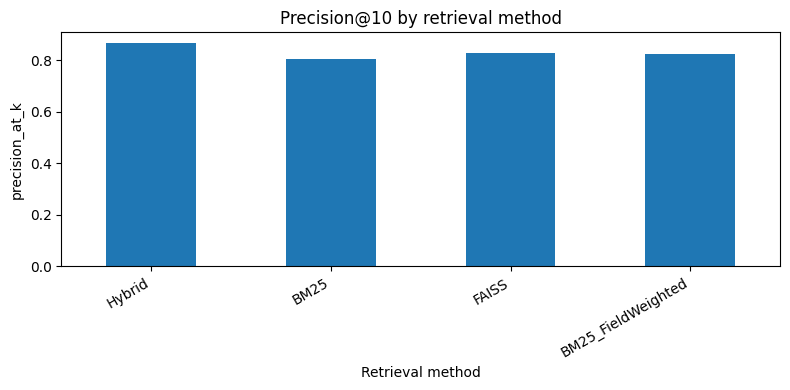

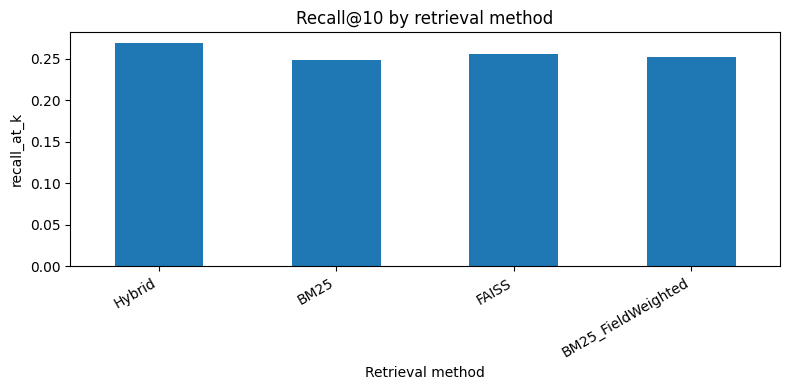

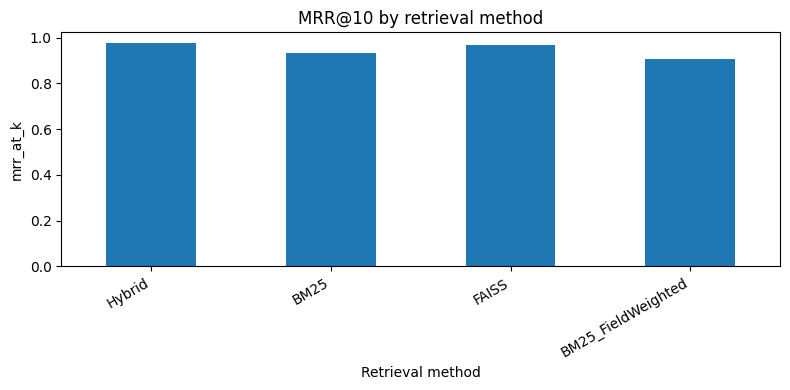

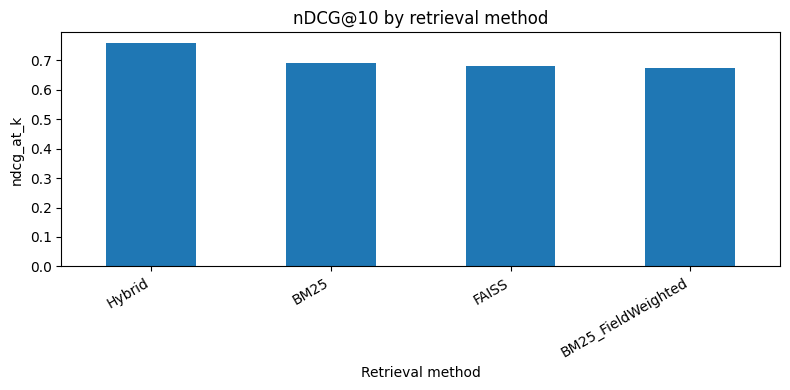

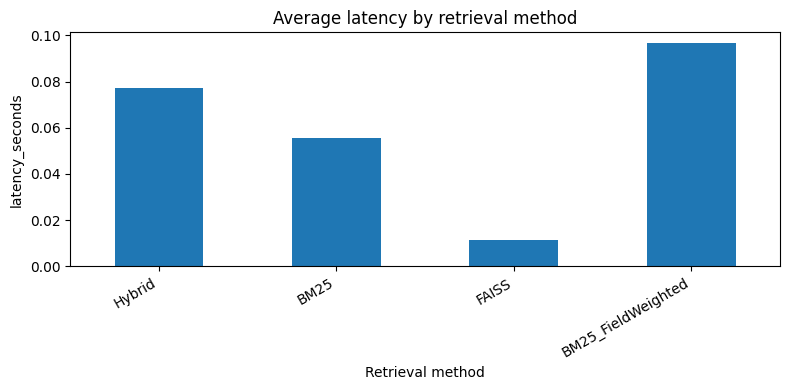

In [69]:
import matplotlib.pyplot as plt


def plot_metric_bar(summary_df, metric, title):
    ax = summary_df.plot(
        x="method",
        y=metric,
        kind="bar",
        legend=False,
        figsize=(8, 4)
    )

    ax.set_title(title)
    ax.set_xlabel("Retrieval method")
    ax.set_ylabel(metric)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


plot_metric_bar(
    retrieval_summary_df,
    "precision_at_k",
    "Precision@10 by retrieval method"
)

plot_metric_bar(
    retrieval_summary_df,
    "recall_at_k",
    "Recall@10 by retrieval method"
)

plot_metric_bar(
    retrieval_summary_df,
    "mrr_at_k",
    "MRR@10 by retrieval method"
)

plot_metric_bar(
    retrieval_summary_df,
    "ndcg_at_k",
    "nDCG@10 by retrieval method"
)

plot_metric_bar(
    retrieval_summary_df,
    "latency_seconds",
    "Average latency by retrieval method"
)

In [70]:
def create_error_analysis_tables(
    query_level_results_df,
    retrieved_documents_df,
    qrels_df,
    queries_df,
    metric="ndcg_at_k"
):
    query_metadata = queries_df[
        [
            "query_id",
            "suitable",
            "notes"
        ]
    ].copy()

    query_scores_df = query_level_results_df.merge(
        query_metadata,
        on="query_id",
        how="left"
    )

    query_metric_summary_df = (
        query_scores_df
        .groupby(
            [
                "query_id",
                "query",
                "category",
                "suitable"
            ],
            as_index=False
        )
        .agg({
            metric: "mean",
            "precision_at_k": "mean",
            "recall_at_k": "mean",
            "mrr_at_k": "mean",
            "latency_seconds": "mean"
        })
        .sort_values(metric, ascending=True)
    )

    method_pivot_df = query_scores_df.pivot_table(
        index=[
            "query_id",
            "query",
            "category",
            "suitable"
        ],
        columns="method",
        values=metric,
        aggfunc="mean"
    ).reset_index()

    method_columns = [
        column
        for column in method_pivot_df.columns
        if column in retrieval_methods_for_evaluation
    ]

    if method_columns:
        method_pivot_df["best_method"] = method_pivot_df[
            method_columns
        ].idxmax(axis=1)

        method_pivot_df["worst_method"] = method_pivot_df[
            method_columns
        ].idxmin(axis=1)

        method_pivot_df["score_spread"] = (
            method_pivot_df[method_columns].max(axis=1)
            -
            method_pivot_df[method_columns].min(axis=1)
        )
    else:
        method_pivot_df["best_method"] = ""
        method_pivot_df["worst_method"] = ""
        method_pivot_df["score_spread"] = np.nan

    qrels_for_merge = qrels_df[
        [
            "query_id",
            "doc_id",
            "relevance"
        ]
    ].copy()

    retrieved_with_relevance_df = retrieved_documents_df.merge(
        qrels_for_merge,
        on=[
            "query_id",
            "doc_id"
        ],
        how="left"
    )

    retrieved_with_relevance_df["relevance"] = (
        retrieved_with_relevance_df["relevance"]
        .fillna(0)
        .astype(int)
    )

    error_template_df = method_pivot_df.copy()
    error_template_df["error_type"] = ""
    error_template_df["manual_interpretation"] = ""
    error_template_df["thesis_takeaway"] = ""

    return (
        query_metric_summary_df,
        method_pivot_df,
        retrieved_with_relevance_df,
        error_template_df
    )


(
    low_performing_queries_df,
    method_comparison_by_query_df,
    retrieved_with_relevance_df,
    error_analysis_template_df
) = create_error_analysis_tables(
    query_level_results_df=query_level_results_df,
    retrieved_documents_df=retrieved_documents_df,
    qrels_df=qrels_df,
    queries_df=queries_df,
    metric="ndcg_at_k"
)

low_performing_queries_df.to_csv(
    ARTIFACT_DIR / "low_performing_queries.csv",
    index=False
)

method_comparison_by_query_df.to_csv(
    ARTIFACT_DIR / "method_comparison_by_query.csv",
    index=False
)

retrieved_with_relevance_df.to_csv(
    ARTIFACT_DIR / "retrieved_documents_with_relevance.csv",
    index=False
)

error_analysis_template_df.to_csv(
    ARTIFACT_DIR / "error_analysis_template.csv",
    index=False
)

display(low_performing_queries_df.head(10))
display(method_comparison_by_query_df.head(10))

print("Saved error-analysis files:")
print(ARTIFACT_DIR / "low_performing_queries.csv")
print(ARTIFACT_DIR / "method_comparison_by_query.csv")
print(ARTIFACT_DIR / "retrieved_documents_with_relevance.csv")
print(ARTIFACT_DIR / "error_analysis_template.csv")

,query_id,query,category,suitable,ndcg_at_k,precision_at_k,recall_at_k,mrr_at_k,latency_seconds
31,Q32,heat protectant for damaged hair,hair concern,Included,0.423549,0.425,0.326923,0.625000,0.061969
39,Q40,gentle exfoliant for acne prone skin,multi-condition,Included,0.448041,0.675,0.293478,0.675000,0.078503
5,Q06,hydrating serum for dry skin,skin concern,Included,0.460119,0.850,0.212500,1.000000,0.063484
16,Q17,body lotion for very dry skin,skin concern,Included,0.480530,0.750,0.214286,1.000000,0.074483
14,Q15,hair oil for frizzy hair,hair concern,Included,0.522459,0.900,0.219512,1.000000,0.065310
9,Q10,sunscreen without white residue,product feature,Included,0.562598,0.900,0.290323,1.000000,0.050903
32,Q33,exfoliating scrub for sensitive skin,multi-condition,Included,0.590929,0.700,0.189189,1.000000,0.062876
37,Q38,transfer resistant foundation,product feature,Included,0.594106,0.625,0.173611,0.645833,0.040658
38,Q39,eyeliner that does not smudge,product feature,Included,0.616480,0.825,0.217105,1.000000,0.066164
2,Q03,anti aging cream for wrinkles,skin concern,Included,0.639045,0.800,0.285714,1.000000,0.061714


method,query_id,query,category,suitable,BM25,BM25_FieldWeighted,FAISS,Hybrid,best_method,worst_method,score_spread
0,Q01,best moisturizer for dry skin,skin concern,Included,0.890520,0.801819,0.660787,0.833557,BM25,FAISS,0.229733
1,Q02,long lasting lipstick,product feature,Included,0.818220,0.673702,0.614988,0.913417,Hybrid,FAISS,0.298429
2,Q03,anti aging cream for wrinkles,skin concern,Included,0.570257,0.690017,0.694038,0.601868,FAISS,BM25,0.123781
3,Q04,shampoo for thinning hair,hair concern,Included,0.722477,0.688414,0.779127,0.797442,Hybrid,BM25_FieldWeighted,0.109028
4,Q05,fragrance free cleanser for sensitive skin,restriction,Included,0.724959,0.698105,0.519333,0.709949,BM25,FAISS,0.205626
5,Q06,hydrating serum for dry skin,skin concern,Included,0.387174,0.440480,0.428548,0.584275,Hybrid,BM25,0.197101
6,Q07,natural deodorant for sensitive skin,natural product,Included,0.866750,0.781675,0.463959,0.702428,BM25,FAISS,0.402791
7,Q08,waterproof mascara,product feature,Included,0.860382,1.000000,0.926636,0.921602,BM25_FieldWeighted,BM25,0.139618
8,Q09,foundation for oily skin,skin type,Included,0.606065,0.592363,0.736461,0.639374,FAISS,BM25_FieldWeighted,0.144098
9,Q10,sunscreen without white residue,product feature,Included,0.427402,0.625297,0.649727,0.547967,FAISS,BM25,0.222325


Saved error-analysis files:
rag_thesis_outputs/low_performing_queries.csv
rag_thesis_outputs/method_comparison_by_query.csv
rag_thesis_outputs/retrieved_documents_with_relevance.csv
rag_thesis_outputs/error_analysis_template.csv


In [71]:
from transformers import pipeline

GENERATION_MODEL_NAME = "microsoft/Phi-3-mini-4k-instruct"

generator = pipeline(
    "text-generation",
    model=GENERATION_MODEL_NAME,
    device_map="auto"
)

print("Generation model loaded:", GENERATION_MODEL_NAME)

config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/16.5k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.94M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

Generation model loaded: microsoft/Phi-3-mini-4k-instruct


In [72]:
def build_rag_context(
    retrieved_results,
    max_documents=5,
    max_chars_per_document=900
):
    context_blocks = []

    for result in retrieved_results[:max_documents]:
        doc_id = result["doc_id"]
        rating = result.get("rating", "")
        title = result.get("title", "")
        text = str(result.get("text", ""))[:max_chars_per_document]

        context_blocks.append(
            f"[doc_id: {doc_id}]\n"
            f"Title: {title}\n"
            f"Rating: {rating}\n"
            f"Review evidence: {text}"
        )

    return "\n\n".join(context_blocks)


def build_rag_prompt(query, retrieved_results):
    context = build_rag_context(
        retrieved_results,
        max_documents=5,
        max_chars_per_document=900
    )

    prompt = f'''
You are an e-commerce product discovery assistant.

Use only the retrieved customer-review evidence below.
If the evidence is not sufficient, say that the reviews do not provide enough information.

User query:
{query}

Retrieved evidence:
{context}

Answer requirements:
- Give a helpful product-discovery answer.
- Mention the main product qualities the user should look for.
- Cite document IDs using [doc_id: number].
- Do not invent claims that are not supported by the evidence.

Answer:
'''

    return prompt.strip()


def generate_rag_answer(
    query,
    retriever=retrieve_hybrid,
    retrieval_k=5,
    max_new_tokens=250
):
    retrieved_results = retriever(
        query,
        k=retrieval_k
    )

    prompt = build_rag_prompt(
        query,
        retrieved_results
    )

    output = generator(
        prompt,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        return_full_text=False
    )

    answer = output[0]["generated_text"].strip()

    return {
        "query": query,
        "answer": answer,
        "retrieved_results": retrieved_results,
        "prompt": prompt
    }

In [73]:
def generate_no_retrieval_answer(
    query,
    max_new_tokens=250
):
    prompt = f'''
You are an e-commerce product discovery assistant.

Answer the user query using only your general model knowledge.
Do not cite retrieved documents because no retrieval context is provided.
If you are uncertain, state the uncertainty.

User query:
{query}

Answer:
'''

    output = generator(
        prompt.strip(),
        max_new_tokens=max_new_tokens,
        do_sample=False,
        return_full_text=False
    )

    return output[0]["generated_text"].strip()

In [74]:
RAG_EVALUATION_QUERY_COUNT = min(
    20,
    len(evaluation_queries_df)
)

category_groups = {
    category: group.sort_values("query_id")
    for category, group
    in evaluation_queries_df.groupby("category")
}

selected_query_ids = []
category_positions = {
    category: 0
    for category in category_groups
}

while len(selected_query_ids) < RAG_EVALUATION_QUERY_COUNT:
    added_in_round = False

    for category in sorted(category_groups):
        group = category_groups[category]
        position = category_positions[category]

        if (
            position < len(group)
            and len(selected_query_ids) < RAG_EVALUATION_QUERY_COUNT
        ):
            selected_query_ids.append(
                group.iloc[position]["query_id"]
            )
            category_positions[category] += 1
            added_in_round = True

    if not added_in_round:
        break

sample_query_ids = selected_query_ids
answer_rows = []

for query_id in sample_query_ids:
    query_row = evaluation_queries_df[
        evaluation_queries_df["query_id"] == query_id
    ].iloc[0]

    rag_result = generate_rag_answer(
        query=query_row["query"],
        retriever=retrieve_hybrid,
        retrieval_k=5,
        max_new_tokens=250
    )

    cited_doc_ids = [
        result["doc_id"]
        for result in rag_result["retrieved_results"]
    ]

    answer_rows.append({
        "query_id": query_id,
        "query": query_row["query"],
        "category": query_row["category"],
        "answer": rag_result["answer"],
        "retrieved_doc_ids": cited_doc_ids
    })

answers_df = pd.DataFrame(answer_rows)

answers_df.to_csv(
    ARTIFACT_DIR / "rag_sample_answers.csv",
    index=False
)

print(
    "RAG answers generated for",
    len(answers_df),
    "category-aware evaluation queries."
)
display(answers_df)

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Both `max_new_tokens` (=2

RAG answers generated for 20 category-aware evaluation queries.


,query_id,query,category,answer,retrieved_doc_ids
0,Q24,cruelty free mascara,ethical preference,"Based on the customer reviews provided, if you...","[21111, 35728, 6387, 30400, 15433]"
1,Q04,shampoo for thinning hair,hair concern,"Based on the customer reviews, a shampoo that ...","[41055, 22951, 39711, 23741, 28903]"
2,Q14,curl defining cream without stiffness,hair type,"Based on the customer reviews, it seems that t...","[26077, 8790, 20845, 18027, 3562]"
3,Q33,exfoliating scrub for sensitive skin,multi-condition,"Based on the customer reviews, for an exfoliat...","[30226, 26203, 36718, 25736, 39509]"
4,Q07,natural deodorant for sensitive skin,natural product,"Based on the customer reviews, it seems that t...","[14889, 30750, 9237, 23115, 22453]"
5,Q02,long lasting lipstick,product feature,"Based on the customer reviews, the main qualit...","[35724, 7027, 10083, 42212, 27778]"
6,Q05,fragrance free cleanser for sensitive skin,restriction,"Based on the customer reviews, a fragrance-fre...","[17642, 16779, 10584, 9509, 41609]"
7,Q01,best moisturizer for dry skin,skin concern,"Based on the customer reviews, the best moistu...","[29985, 27992, 39363, 41117, 20860]"
8,Q09,foundation for oily skin,skin type,"For oily skin, the best foundation according t...","[34796, 3418, 43021, 30972, 42077]"
9,Q34,moisturizer suitable under makeup,usage requirement,"Based on the customer reviews, a moisturizer t...","[39567, 33099, 8995, 14105, 13244]"


In [75]:
baseline_answer_rows = []

for query_id in sample_query_ids:
    query_row = queries_df[
        queries_df["query_id"] == query_id
    ].iloc[0]

    baseline_answer = generate_no_retrieval_answer(
        query=query_row["query"],
        max_new_tokens=250
    )

    baseline_answer_rows.append({
        "query_id": query_id,
        "query": query_row["query"],
        "category": query_row["category"],
        "generation_method": "No_Retrieval_Generator",
        "answer": baseline_answer,
        "retrieved_doc_ids": []
    })

rag_answer_rows = answers_df.copy()
rag_answer_rows["generation_method"] = "RAG_Hybrid"

generation_comparison_df = pd.concat(
    [
        rag_answer_rows[
            [
                "query_id",
                "query",
                "category",
                "generation_method",
                "answer",
                "retrieved_doc_ids"
            ]
        ],
        pd.DataFrame(baseline_answer_rows)
    ],
    ignore_index=True
)

generation_comparison_df.to_csv(
    ARTIFACT_DIR / "rag_vs_no_retrieval_answers.csv",
    index=False
)

display(generation_comparison_df)

[transformers] Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

,query_id,query,category,generation_method,answer,retrieved_doc_ids
0,Q24,cruelty free mascara,ethical preference,RAG_Hybrid,"Based on the customer reviews provided, if you...","[21111, 35728, 6387, 30400, 15433]"
1,Q04,shampoo for thinning hair,hair concern,RAG_Hybrid,"Based on the customer reviews, a shampoo that ...","[41055, 22951, 39711, 23741, 28903]"
2,Q14,curl defining cream without stiffness,hair type,RAG_Hybrid,"Based on the customer reviews, it seems that t...","[26077, 8790, 20845, 18027, 3562]"
3,Q33,exfoliating scrub for sensitive skin,multi-condition,RAG_Hybrid,"Based on the customer reviews, for an exfoliat...","[30226, 26203, 36718, 25736, 39509]"
4,Q07,natural deodorant for sensitive skin,natural product,RAG_Hybrid,"Based on the customer reviews, it seems that t...","[14889, 30750, 9237, 23115, 22453]"
5,Q02,long lasting lipstick,product feature,RAG_Hybrid,"Based on the customer reviews, the main qualit...","[35724, 7027, 10083, 42212, 27778]"
6,Q05,fragrance free cleanser for sensitive skin,restriction,RAG_Hybrid,"Based on the customer reviews, a fragrance-fre...","[17642, 16779, 10584, 9509, 41609]"
7,Q01,best moisturizer for dry skin,skin concern,RAG_Hybrid,"Based on the customer reviews, the best moistu...","[29985, 27992, 39363, 41117, 20860]"
8,Q09,foundation for oily skin,skin type,RAG_Hybrid,"For oily skin, the best foundation according t...","[34796, 3418, 43021, 30972, 42077]"
9,Q34,moisturizer suitable under makeup,usage requirement,RAG_Hybrid,"Based on the customer reviews, a moisturizer t...","[39567, 33099, 8995, 14105, 13244]"


In [76]:
# These values are diagnostic proxies, not validated measures of faithfulness or coherence.
ANSWER_EVAL_STOPWORDS = {
    "a", "an", "and", "are", "as", "at", "be", "by", "for", "from",
    "in", "is", "it", "of", "on", "or", "that", "the", "to", "with",
    "without", "you", "your", "this", "these", "those", "should"
}


def content_terms(text):
    return [
        token
        for token in clean_text(text).split()
        if token not in ANSWER_EVAL_STOPWORDS and len(token) > 2
    ]


def evaluate_generated_answer_proxy(
    query,
    answer,
    retrieved_results=None
):
    query_terms = set(content_terms(query))
    answer_terms = content_terms(answer)
    answer_term_set = set(answer_terms)

    if retrieved_results is not None:
        context_text = " ".join(
            str(result.get("text", ""))
            for result in retrieved_results
        )
        context_terms = set(content_terms(context_text))
    else:
        context_terms = set()

    query_coverage = (
        len(query_terms.intersection(answer_term_set)) / len(query_terms)
        if query_terms
        else np.nan
    )

    context_support_proxy = (
        len(answer_term_set.intersection(context_terms)) / len(answer_term_set)
        if answer_term_set and context_terms
        else np.nan
    )

    citation_count = answer.count("[doc_id:")

    repetition_ratio = (
        1 - (len(answer_term_set) / len(answer_terms))
        if answer_terms
        else 1.0
    )

    word_count = len(answer.split())
    length_score = 1.0 if 30 <= word_count <= 180 else 0.5
    coherence_proxy = max(
        0.0,
        length_score - repetition_ratio
    )

    return {
        "query_coverage": query_coverage,
        "context_support_proxy": context_support_proxy,
        "citation_count": citation_count,
        "answer_word_count": word_count,
        "repetition_ratio": repetition_ratio,
        "coherence_proxy": coherence_proxy
    }


answer_metric_rows = []

for _, row in generation_comparison_df.iterrows():
    if row["generation_method"] == "RAG_Hybrid":
        retrieved_results = retrieve_hybrid(
            row["query"],
            k=5
        )
    else:
        retrieved_results = None

    metric_row = evaluate_generated_answer_proxy(
        query=row["query"],
        answer=row["answer"],
        retrieved_results=retrieved_results
    )

    metric_row.update({
        "query_id": row["query_id"],
        "query": row["query"],
        "category": row["category"],
        "generation_method": row["generation_method"]
    })

    answer_metric_rows.append(metric_row)

rag_output_metrics_df = pd.DataFrame(answer_metric_rows)

rag_output_summary_df = (
    rag_output_metrics_df
    .groupby("generation_method", as_index=False)
    .agg({
        "query_coverage": "mean",
        "context_support_proxy": "mean",
        "citation_count": "mean",
        "answer_word_count": "mean",
        "repetition_ratio": "mean",
        "coherence_proxy": "mean"
    })
)

rag_output_metrics_df.to_csv(
    ARTIFACT_DIR / "rag_output_quantitative_evaluation.csv",
    index=False
)

rag_output_summary_df.to_csv(
    ARTIFACT_DIR / "rag_output_quantitative_summary.csv",
    index=False
)

display(rag_output_metrics_df)
display(rag_output_summary_df)

,query_coverage,context_support_proxy,citation_count,answer_word_count,repetition_ratio,coherence_proxy,query_id,query,category,generation_method
0,1.0,0.267857,4,133,0.308642,0.691358,Q24,cruelty free mascara,ethical preference,RAG_Hybrid
1,1.0,0.179104,5,142,0.211765,0.788235,Q04,shampoo for thinning hair,hair concern,RAG_Hybrid
2,1.0,0.225806,5,155,0.347368,0.652632,Q14,curl defining cream without stiffness,hair type,RAG_Hybrid
3,1.0,0.131148,3,143,0.306818,0.693182,Q33,exfoliating scrub for sensitive skin,multi-condition,RAG_Hybrid
4,1.0,0.117647,3,146,0.200000,0.800000,Q07,natural deodorant for sensitive skin,natural product,RAG_Hybrid
5,1.0,0.188406,4,145,0.215909,0.784091,Q02,long lasting lipstick,product feature,RAG_Hybrid
6,1.0,0.267857,7,117,0.263158,0.736842,Q05,fragrance free cleanser for sensitive skin,restriction,RAG_Hybrid
7,1.0,0.236111,4,151,0.265306,0.734694,Q01,best moisturizer for dry skin,skin concern,RAG_Hybrid
8,1.0,0.527778,3,140,0.280000,0.720000,Q09,foundation for oily skin,skin type,RAG_Hybrid
9,1.0,0.267857,7,125,0.291139,0.708861,Q34,moisturizer suitable under makeup,usage requirement,RAG_Hybrid


,generation_method,query_coverage,context_support_proxy,citation_count,answer_word_count,repetition_ratio,coherence_proxy
0,No_Retrieval_Generator,0.99,NaN,0.0,148.85,0.273192,0.726808
1,RAG_Hybrid,1.00,0.251006,3.9,144.40,0.277318,0.722682


In [77]:
human_evaluation_source_df = generation_comparison_df.copy()

human_evaluation_source_df = (
    human_evaluation_source_df
    .sample(
        frac=1,
        random_state=EXPERIMENT_RANDOM_SEED
    )
    .reset_index(drop=True)
)

human_evaluation_source_df["answer_id"] = [
    f"A{position:03d}"
    for position in range(
        1,
        len(human_evaluation_source_df) + 1
    )
]

human_evaluation_key_df = human_evaluation_source_df[
    [
        "answer_id",
        "query_id",
        "generation_method"
    ]
].copy()

answer_evaluation_df = human_evaluation_source_df[
    [
        "answer_id",
        "query_id",
        "query",
        "category",
        "answer"
    ]
].copy()

answer_evaluation_df["relevance_1_to_5"] = ""
answer_evaluation_df["groundedness_1_to_5"] = ""
answer_evaluation_df["helpfulness_1_to_5"] = ""
answer_evaluation_df["clarity_1_to_5"] = ""
answer_evaluation_df["hallucination_risk_1_to_5"] = ""
answer_evaluation_df["evaluator_notes"] = ""

answer_evaluation_path = (
    ARTIFACT_DIR /
    "rag_answer_evaluation_BLINDED.csv"
)

answer_evaluation_key_path = (
    ARTIFACT_DIR /
    "rag_answer_evaluation_method_key.csv"
)

answer_evaluation_df.to_csv(
    answer_evaluation_path,
    index=False
)

human_evaluation_key_df.to_csv(
    answer_evaluation_key_path,
    index=False
)

print(
    "Fill the blinded evaluation file without opening the method key:"
)
print(answer_evaluation_path)
print(
    "After scoring, save it as "
    "rag_answer_evaluation_COMPLETED.csv."
)
print(
    "Keep this method key hidden until scoring is complete:"
)
print(answer_evaluation_key_path)

display(answer_evaluation_df.head())

Fill the blinded evaluation file without opening the method key:
rag_thesis_outputs/rag_answer_evaluation_BLINDED.csv
After scoring, save it as rag_answer_evaluation_COMPLETED.csv.
Keep this method key hidden until scoring is complete:
rag_thesis_outputs/rag_answer_evaluation_method_key.csv


,answer_id,query_id,query,category,answer,relevance_1_to_5,groundedness_1_to_5,helpfulness_1_to_5,clarity_1_to_5,hallucination_risk_1_to_5,evaluator_notes
0,A001,Q15,hair oil for frizzy hair,hair concern,"For frizzy hair, the product that seems to be ...",,,,,,
1,A002,Q21,alcohol free toner for sensitive skin,restriction,"Based on the reviews provided, it seems that t...",,,,,,
2,A003,Q08,waterproof mascara,product feature,"Based on the customer reviews, it seems that t...",,,,,,
3,A004,Q05,fragrance free cleanser for sensitive skin,restriction,"I'm sorry, but I can't provide real-time or sp...",,,,,,
4,A005,Q07,natural deodorant for sensitive skin,natural product,"Based on the customer reviews, it seems that t...",,,,,,


In [78]:
completed_human_evaluation_path = (
    ARTIFACT_DIR /
    "rag_answer_evaluation_COMPLETED.csv"
)

if completed_human_evaluation_path.exists():
    completed_human_evaluation_df = pd.read_csv(
        completed_human_evaluation_path
    )

    score_columns = [
        "relevance_1_to_5",
        "groundedness_1_to_5",
        "helpfulness_1_to_5",
        "clarity_1_to_5",
        "hallucination_risk_1_to_5"
    ]

    for score_column in score_columns:
        completed_human_evaluation_df[
            score_column
        ] = pd.to_numeric(
            completed_human_evaluation_df[
                score_column
            ],
            errors="coerce"
        )

        invalid_scores = (
            completed_human_evaluation_df[
                score_column
            ].isna()
            |
            ~completed_human_evaluation_df[
                score_column
            ].between(1, 5)
        )

        if invalid_scores.any():
            raise ValueError(
                f"{score_column} contains missing or invalid scores. "
                "Every answer must receive an integer score from 1 to 5."
            )

    completed_human_evaluation_df = (
        completed_human_evaluation_df
        .merge(
            human_evaluation_key_df,
            on=[
                "answer_id",
                "query_id"
            ],
            how="left",
            validate="one_to_one"
        )
    )

    human_evaluation_summary_df = (
        completed_human_evaluation_df
        .groupby(
            "generation_method",
            as_index=False
        )
        .agg({
            "relevance_1_to_5": [
                "mean",
                "std"
            ],
            "groundedness_1_to_5": [
                "mean",
                "std"
            ],
            "helpfulness_1_to_5": [
                "mean",
                "std"
            ],
            "clarity_1_to_5": [
                "mean",
                "std"
            ],
            "hallucination_risk_1_to_5": [
                "mean",
                "std"
            ]
        })
    )

    human_evaluation_summary_df.columns = [
        "_".join(
            str(part)
            for part in column
            if str(part)
        ).rstrip("_")
        if isinstance(column, tuple)
        else column
        for column in human_evaluation_summary_df.columns
    ]

    completed_human_evaluation_df.to_csv(
        ARTIFACT_DIR /
        "rag_answer_evaluation_unblinded.csv",
        index=False
    )

    human_evaluation_summary_df.to_csv(
        ARTIFACT_DIR /
        "rag_answer_human_evaluation_summary.csv",
        index=False
    )

    display(human_evaluation_summary_df)
else:
    print(
        "Human evaluation is not complete yet. Fill "
        "rag_answer_evaluation_BLINDED.csv and save the completed "
        "file as rag_answer_evaluation_COMPLETED.csv."
    )

,generation_method,relevance_1_to_5_mean,relevance_1_to_5_std,groundedness_1_to_5_mean,groundedness_1_to_5_std,helpfulness_1_to_5_mean,helpfulness_1_to_5_std,clarity_1_to_5_mean,clarity_1_to_5_std,hallucination_risk_1_to_5_mean,hallucination_risk_1_to_5_std
0,No_Retrieval_Generator,3.15,1.308877,1.00,0.00000,2.60,0.994723,1.85,0.587143,3.30,1.218282
1,RAG_Hybrid,4.50,0.945905,2.85,0.67082,3.65,0.745160,2.20,0.523148,3.05,0.604805


# Final Thesis-Readiness Checklist

Before writing the results chapter:

1. Re-run the notebook from the query-inspection section onward.
2. Audit `qrels_stratified_audit_sample.csv`, especially labels `1` and `2`.
3. Confirm judgment coverage is `1.0` for every method at each reported \(k\).
4. Report all 40 predefined queries in the main retrieval evaluation.
5. Use Holm-adjusted significance results rather than unadjusted \(p\)-values.
6. Complete the blinded human evaluation for both RAG and no-retrieval answers.
7. Treat automatic answer metrics as diagnostics, not validated faithfulness metrics.
8. Base conclusions on effect sizes, confidence intervals, and adjusted significance tests.

In [79]:
final_readiness_checks = {
    "all_40_queries_evaluated": (
        len(evaluation_queries_df) == len(queries_df) == 40
    ),
    "manual_qrels_loaded": (
        qrels_source == "validated manual relevance labels"
    ),
    "judgment_coverage_complete": (
        query_level_results_df[
            "judgment_coverage_at_k"
        ].min() == 1.0
    ),
    "holm_adjustment_available": (
        "p_value_holm_adjusted"
        in statistical_validation_df.columns
    ),
    "human_evaluation_completed": (
        ARTIFACT_DIR /
        "rag_answer_evaluation_COMPLETED.csv"
    ).exists()
}

final_readiness_df = pd.DataFrame([
    {
        "check": check_name,
        "passed": passed
    }
    for check_name, passed
    in final_readiness_checks.items()
])

display(final_readiness_df)

if not final_readiness_df["passed"].all():
    print(
        "The notebook is technically complete, but the failed checks "
        "must be resolved before reporting final thesis conclusions."
    )
else:
    print(
        "All final readiness checks passed."
    )

,check,passed
0,all_40_queries_evaluated,True
1,manual_qrels_loaded,True
2,judgment_coverage_complete,True
3,holm_adjustment_available,True
4,human_evaluation_completed,True


All final readiness checks passed.
